In [1]:
# from mca_shared_izzy.ice_vels_ocean_air_forcing import ice_vel_removed_nans
#from mca_shared_izzy.ice_vels_ocean_air_forcing import time_sidc_eumetsat
# from mca_shared_izzyv1 import ws_curl
#from mca_shared_izzy.mca_shared_si_conc import dot_xa_masked
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import xeofs as xe
from pygments.modeline import modeline_re

from geometry_izzyv1 import grad_sphere
from regression_izzyv1 import linregress_3D
import cartopy.crs as ccrs
crs = ccrs.PlateCarree()
import warnings
import os
from pyproj import Proj, Transformer
import requests
from bs4 import BeautifulSoup
#import copernicusmarine as cm
warnings.filterwarnings('ignore')

In [3]:
# constant
rho_a = 1.225 # air density kg m-3
Cd = 1.5e-3 # drag coeff

In [4]:
gridtype = 'remapcon'

In [5]:
import netCDF4
import h5netcdf

In [6]:
# #downloading SI_drift data noaa
# archive_url = "https://noaadata.apps.nsidc.org/NOAA/G02202_V5/south/monthly/"
#
# r = requests.get(archive_url)
#
# data = BeautifulSoup(r.text, "html.parser")
#
# for l in data.find_all("a")[1:]:
# 	r = requests.get(archive_url + l["href"])
# 	with open(l["href"], "wb") as f:
#     	         f.write(r.content)

In [7]:
# #downloading SI_conc data noaa
# archive_url_conc = "https://noaadata.apps.nsidc.org/NOAA/G02202_V4/south/monthly/"
#
# r_conc = requests.get(archive_url_conc)
#
# data_conc = BeautifulSoup(r_conc.text, "html.parser")
#
# for l in data_conc.find_all("a")[1:]:
# 	r_conc = requests.get(archive_url_conc + l["href"])
# 	with open(l["href"], "wb") as f:
#     	         f.write(r_conc.content)

In [8]:
# dot dataset
path = '/Users/iw2g24/PycharmProjects/SSH_project/'
print(path)
fig_path = '/Users/iw2g24/PycharmProjects/SSH_project/results/NPP_mca/'
ds = xr.open_dataset(path + 'Data/dot_all_30bmedian_goco05c_sig3_1.nc')
print(ds)
# ERA5 remap dataset
ds_era5 = xr.open_dataset(path + 'Data/ERA5_u10v10_Antartica_2000-2023_' + gridtype + '.nc')

/Users/iw2g24/PycharmProjects/SSH_project/
<xarray.Dataset> Size: 109MB
Dimensions:          (longitude: 360, latitude: 64, time: 196, edge_lat: 65,
                      edge_lon: 361)
Coordinates:
  * longitude        (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * latitude         (latitude) float64 512B -81.75 -81.25 ... -50.75 -50.25
  * time             (time) datetime64[ns] 2kB 2002-07-01 ... 2018-10-01
  * edge_lat         (edge_lat) float64 520B -82.0 -81.5 -81.0 ... -50.5 -50.0
  * edge_lon         (edge_lon) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0
Data variables:
    dot              (longitude, latitude, time) float64 36MB ...
    ug               (longitude, latitude, time) float64 36MB ...
    vg               (longitude, latitude, time) float64 36MB ...
    land_mask        (longitude, latitude) float64 184kB ...
    intersat_offset  float64 8B ...
Attributes:
    history:      Created 08/01/2022, 00:5223
    description:  ENVISAT + CryoSat2 altimetry 

In [9]:
path_ds = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'
print(path_ds)
WSC_eumetsat_ds = xr.open_dataset(path_ds + 'WSC_eumetsat_masked_v2.nc')
WSC_nsidc_ds = xr.open_dataset(path_ds + 'WSC_nsidc_masked_v2.nc')
sidc_eumetsat_ds = xr.open_dataset(path_ds + 'sidc_eumetsat_masked_v2.nc')
sidc_eumetsat_ds = sidc_eumetsat_ds.rename({'__xarray_dataarray_variable__': 'sidc'})
sidc_nsidc_ds = xr.open_dataset(path_ds + 'sidc_nsidc_masked_v2.nc')
sidc_nsidc_ds = sidc_nsidc_ds.rename({'__xarray_dataarray_variable__': 'sidc'})
tau_nsidc_ds = xr.open_dataset(path_ds + 'tau_nsidc_ds_v4.nc')
tau_eumetsat_ds = xr.open_dataset(path_ds + 'tau_eumetsat_ds_v4.nc')
# tau_nsidc_ds = xr.open_dataset(path + 'tau_nsidc_ds_v3.nc')
# tau_eumetsat_ds = xr.open_dataset(path + 'tau_eumetsat_ds_v3.nc')
dot_masked_ds = xr.open_dataset(path_ds + 'dot_masked.nc')
OSC_eumetsat_ds = xr.open_dataset(path_ds+'OSC_eumetsat_ds_v2.nc')
OSC_nsidc_ds = xr.open_dataset(path_ds+'OSC_nsidc_ds_v2.nc')

/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/


In [10]:

print(sidc_eumetsat_ds)

<xarray.Dataset> Size: 36MB
Dimensions:  (time: 196, lat: 64, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-07-01 2002-08-01 ... 2018-10-01
  * lat      (lat) float64 512B -81.75 -81.25 -80.75 ... -51.25 -50.75 -50.25
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    sidc     (time, lat, lon) float64 36MB ...


In [11]:
ds_NPP = xr.open_dataset(path + 'Data/NPP_anomalies' + '.nc')
print(ds_NPP)

ds_NPP_masked = xr.open_dataset(path + 'Data/NPP_anomalies_masked' + '.nc')
print(ds_NPP_masked)

ds_NPP = ds_NPP.transpose('year', 'lat', 'lon')  # shape becomes (22, 480, 4320)
ds_NPP = ds_NPP.sortby(['lat', 'lon'])


ds_NPP_masked = ds_NPP_masked.transpose('year', 'lat', 'lon')  # shape becomes (22, 480, 4320)
ds_NPP_masked = ds_NPP_masked.sortby(['lat', 'lon'])
print(ds_NPP_masked)
print(ds_NPP)




<xarray.Dataset> Size: 365MB
Dimensions:       (lat: 480, lon: 4320, year: 22)
Coordinates:
  * lat           (lat) float64 4kB -50.12 -50.21 -50.29 ... -89.96 -90.04
  * lon           (lon) float64 35kB -179.9 -179.8 -179.7 ... 179.9 180.0 180.0
  * year          (year) float64 176B 2.003e+03 2.004e+03 ... 2.024e+03
Data variables:
    OpenOceanNPP  (year, lon, lat) float64 365MB ...
<xarray.Dataset> Size: 730MB
Dimensions:                (lat: 480, lon: 4320, year: 22)
Coordinates:
  * lat                    (lat) float64 4kB -50.12 -50.21 ... -89.96 -90.04
  * lon                    (lon) float64 35kB -179.9 -179.8 ... 180.0 180.0
  * year                   (year) float64 176B 2.003e+03 2.004e+03 ... 2.024e+03
Data variables:
    OpenOceanNPP_masked    (year, lon, lat) float64 365MB ...
    ShelfRegionNPP_masked  (year, lon, lat) float64 365MB ...
<xarray.Dataset> Size: 730MB
Dimensions:                (lat: 480, lon: 4320, year: 22)
Coordinates:
  * lat                    (lat) flo

plotted data size (22, 480, 4320)


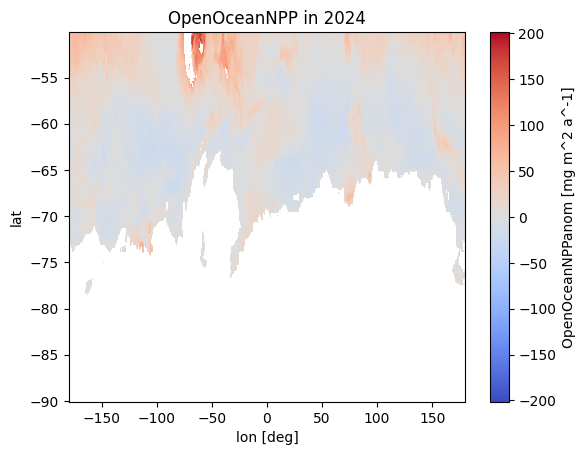

plotted data size (22, 480, 4320)


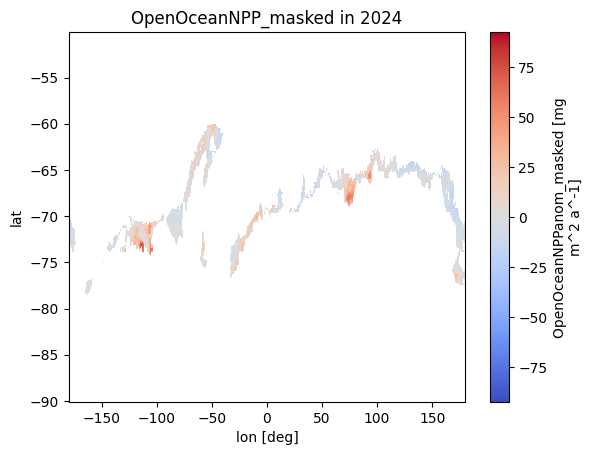

plotted data size (22, 480, 4320)


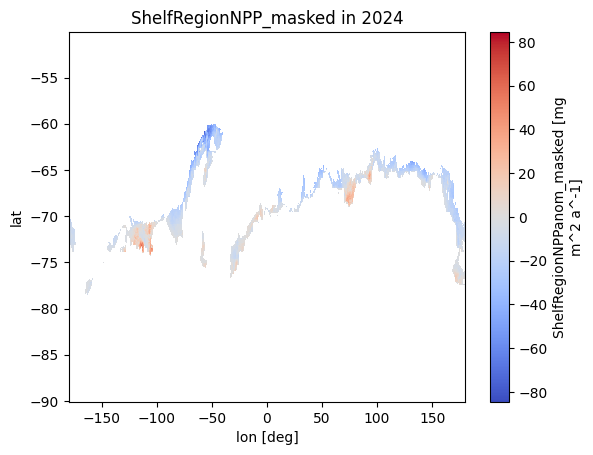

In [12]:
variable_name = "OpenOceanNPP"
data_to_plot = ds_NPP[variable_name]
print("plotted data size",data_to_plot.shape)

# Plot using xarray's built-in method
data_to_plot.isel(year=0).plot(cmap="coolwarm")
plt.title(f"{variable_name} in {float(ds_NPP.year[-1].values):.0f}")
plt.show()

variable_name = "OpenOceanNPP_masked"
data_to_plot = ds_NPP_masked[variable_name]
print("plotted data size",data_to_plot.shape)

# Plot using xarray's built-in method
data_to_plot.isel(year=0).plot(cmap="coolwarm")
plt.title(f"{variable_name} in {float(ds_NPP.year[-1].values):.0f}")
plt.show()

variable_name = "ShelfRegionNPP_masked"
data_to_plot = ds_NPP_masked[variable_name]
print("plotted data size",data_to_plot.shape)

# Plot using xarray's built-in method
data_to_plot.isel(year=0).plot(cmap="coolwarm")
plt.title(f"{variable_name} in {float(ds_NPP.year[-1].values):.0f}")
plt.show()

In [13]:
# plt.tight_layout()
# #create array with monthly average contribution to annual integrated (summed) NNP
# ann_NPP = ds_NPP['OpenOceanNPP'].values
# monthly_NPP = np.repeat(ann_NPP / 12, repeats=12, axis=0)
# print(len(ann_NPP), len(monthly_NPP))
# # #select appropriate times - match to dot length/extent
# # monthly_NPP = monthly_NPP[tstart_NPP:tend_NPP]
# # print(len(monthly_NPP))

In [14]:
# print(ds_NPP.dims)
# print(ds_NPP['OpenOceanNPP'].shape)
# print(ann_NPP.shape)
# print(monthly_NPP.shape)

In [15]:
# #add monthly dates and NPP values to ds_NPP
# ds_NPP['monthly_NPP']= (('monthly_NPP_time', 'lon', 'lat'), monthly_NPP)
# ds_NPP = ds.assign_coords(monthly_NPP_time = ('monthly_NPP_time', monthly_NPP_time))
# print(ds_NPP)

In [16]:
# change coordinates from (lon,lat,time) to (time,lat,lon) as ERA5
lon = ds['longitude'].values; lat = ds['latitude'].values
dot_all = ds['dot'].values
dot = np.zeros((dot_all.shape[2], dot_all.shape[1], dot_all.shape[0]))
for t in range(0,dot_all.shape[2]):
    for i in range(0,dot_all.shape[1]):
        for j in range(0,dot_all.shape[0]):
            dot[t,i,j] = dot_all[j,i,t].copy()
seamask = dot[0].copy()/dot[0]
seamask[seamask == 0] = np.nan
del dot_all

In [17]:
# make lon lat 2d
llon = np.zeros((dot.shape[1],dot.shape[2]))
for i in range(0,dot.shape[1]):
    llon[i,:] = lon
llat = np.zeros((dot.shape[1],dot.shape[2]))
for i in range(0,dot.shape[2]):
    llat[:,i] = lat

In [18]:
dot.shape

(196, 64, 360)

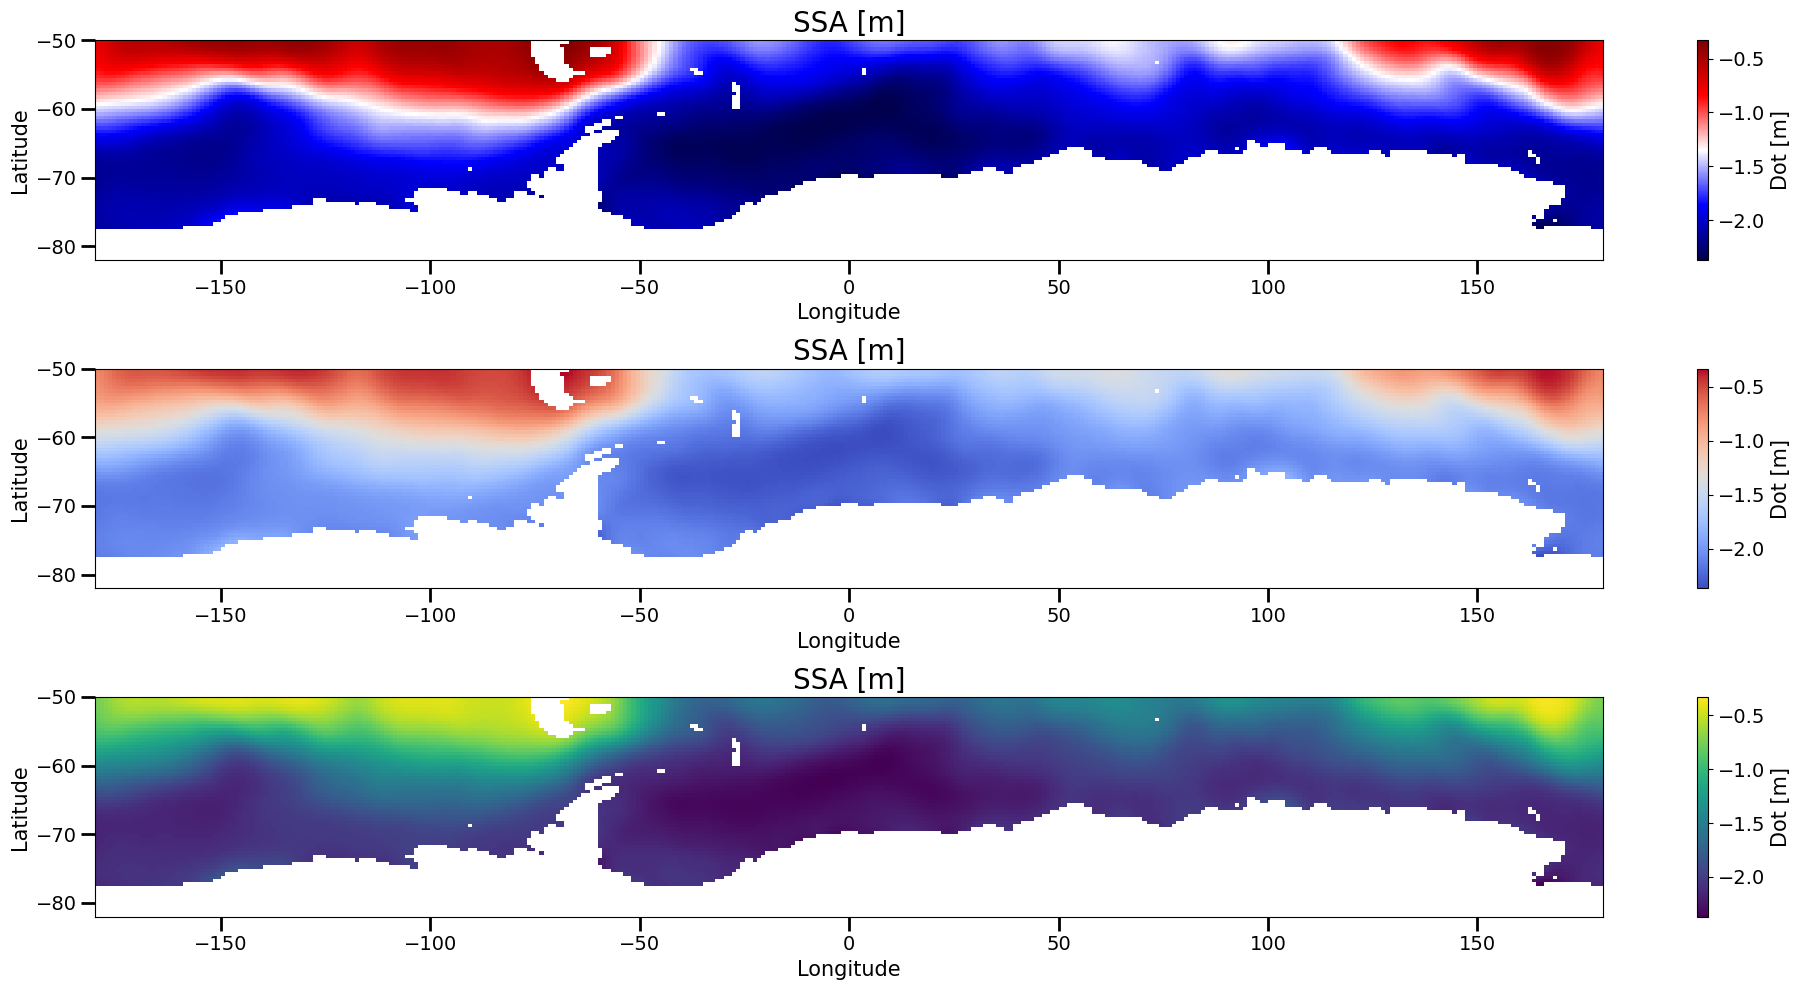

In [19]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(20, 10))

pc1 = axes[0].pcolormesh(llon,llat,dot[0], cmap='seismic')
axes[0].tick_params(axis='both', which='major', length=10, width=2, labelsize=14)
axes[0].set_title('SSA [m]', fontsize=20)
axes[0].set_xlabel('Longitude', fontsize=15)
axes[0].set_ylabel('Latitude', fontsize=15)
cbar1 = fig.colorbar(pc1, ax=axes[0])
cbar1.set_label('Dot [m]', fontsize=15)
cbar1.ax.tick_params(labelsize=14)

pc2 = axes[1].pcolormesh(llon,llat,dot[0], cmap='coolwarm')
axes[1].tick_params(axis='both', which='major', length=10, width=2, labelsize=14)
axes[1].set_title('SSA [m]', fontsize=20)
axes[1].set_xlabel('Longitude', fontsize=15)
axes[1].set_ylabel('Latitude', fontsize=15)
cbar2 = fig.colorbar(pc2, ax=axes[1])
cbar2.set_label('Dot [m]', fontsize=15)
cbar2.ax.tick_params(labelsize=14)

pc3 = axes[2].pcolormesh(llon,llat,dot[0], cmap='viridis')
axes[2].tick_params(axis='both', which='major', length=10, width=2, labelsize=14)
axes[2].set_title('SSA [m]', fontsize=20)
axes[2].set_xlabel('Longitude', fontsize=15)
axes[2].set_ylabel('Latitude', fontsize=15)
cbar3 = fig.colorbar(pc3, ax=axes[2])
cbar3.set_label('Dot [m]', fontsize=15)
cbar3.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

In [20]:
# total_nans = dot_xa.isnull().sum().item()
# print(f"Total NaN values in dot_xa: {total_nans}")


In [21]:
# time
time_era5 = ds_era5['time'].values
time_dot = ds['time'].values
time_NPP = ds_NPP['year'].values
time_tau = tau_nsidc_ds['time'].values
time_sidc_eumetsat = sidc_eumetsat_ds['time'].values

In [22]:
#create new NPP dates where they are monthly (not annual)
start_year = int(time_NPP[0])
end_year = int(time_NPP[-1])
monthly_NPP_time = pd.date_range(start=f'{start_year}',end=f'{end_year}', freq='MS')
monthly_NPP_time = monthly_NPP_time.strftime('%Y-%m-%dT%H:%M:%S.%f000')
print(monthly_NPP_time)
print(time_NPP)

Index(['2003-01-01T00:00:00.000000000', '2003-02-01T00:00:00.000000000',
       '2003-03-01T00:00:00.000000000', '2003-04-01T00:00:00.000000000',
       '2003-05-01T00:00:00.000000000', '2003-06-01T00:00:00.000000000',
       '2003-07-01T00:00:00.000000000', '2003-08-01T00:00:00.000000000',
       '2003-09-01T00:00:00.000000000', '2003-10-01T00:00:00.000000000',
       ...
       '2023-04-01T00:00:00.000000000', '2023-05-01T00:00:00.000000000',
       '2023-06-01T00:00:00.000000000', '2023-07-01T00:00:00.000000000',
       '2023-08-01T00:00:00.000000000', '2023-09-01T00:00:00.000000000',
       '2023-10-01T00:00:00.000000000', '2023-11-01T00:00:00.000000000',
       '2023-12-01T00:00:00.000000000', '2024-01-01T00:00:00.000000000'],
      dtype='object', length=253)
[2003. 2004. 2005. 2006. 2007. 2008. 2009. 2010. 2011. 2012. 2013. 2014.
 2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022. 2023. 2024.]


In [23]:
#print(time_era5)
print(time_dot[6],time_dot[-1])
print(time_era5[36],time_era5[225])
print(time_tau[6], time_tau[-1])
print(time_sidc_eumetsat[6], time_sidc_eumetsat[-1])
print(monthly_NPP_time[0],monthly_NPP_time[189])


2003-01-01T00:00:00.000000000 2018-10-01T00:00:00.000000000
2003-01-01T00:00:00.000000000 2018-10-01T00:00:00.000000000
2003-01-01T00:00:00.000000000 2018-10-01T00:00:00.000000000
2003-01-01T00:00:00.000000000 2018-10-01T00:00:00.000000000
2003-01-01T00:00:00.000000000 2018-10-01T00:00:00.000000000


In [24]:
tstart_dot = 6
tend_dot = -1
tstart_tau = 6
tend_tau = -1
tstart_era5_NPP = 36
tstart_era5 = 30
tend_era5 = 226 # +1 respect cell above
tstart_NPP = 0
tend_NPP = 190 #+1 wrt cell above

In [25]:
# select wind
u10 = ds_era5['u10'][tstart_era5:tend_era5].values
v10 = ds_era5['v10'][tstart_era5:tend_era5].values

# map lat in lat[::-1] when using gridboxmean mapping
# since lat in ERA5 goes from -50 to -80 instead in dot goes from -80 to -50
if gridtype == 'gridboxmean':
    print('you are using ',gridtype)
    u10 = u10[:,::-1,:]  
    v10 = v10[:,::-1,:]  
    
u10 = u10*seamask
v10 = v10*seamask
U = np.sqrt(u10**2. + v10**2.)

In [26]:
# wind stress
tau_x = rho_a*Cd*U*u10 #zonal wind
tau_y = rho_a*Cd*U*v10 #meridional wind

print('zonal wind:', tau_x)
print('meridional wind:', tau_y)

zonal wind: [[[       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  ...
  [0.02068101 0.01995691 0.01893414 ... 0.02478185 0.02406133 0.02285532]
  [0.02073882 0.02002566 0.01897176 ... 0.02542477 0.02491941 0.02391698]
  [0.02081135 0.01977531 0.01851727 ... 0.02508504 0.02510456 0.0242639 ]]

 [[       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  ...
  [0.02263992 0.02283532 0.02308318 ... 0.0202767  0.02100487 0.02146125]
  [0.01919219 0.01941123 0.01973684 ... 0.01726765 0.01758919 0.01786926]
  [0.01712514 0.01781618 0.01820304 ... 0.01602753 0.01570514 0.01575291]]

 [[       nan        nan        nan ...        nan        nan        nan]
  [       

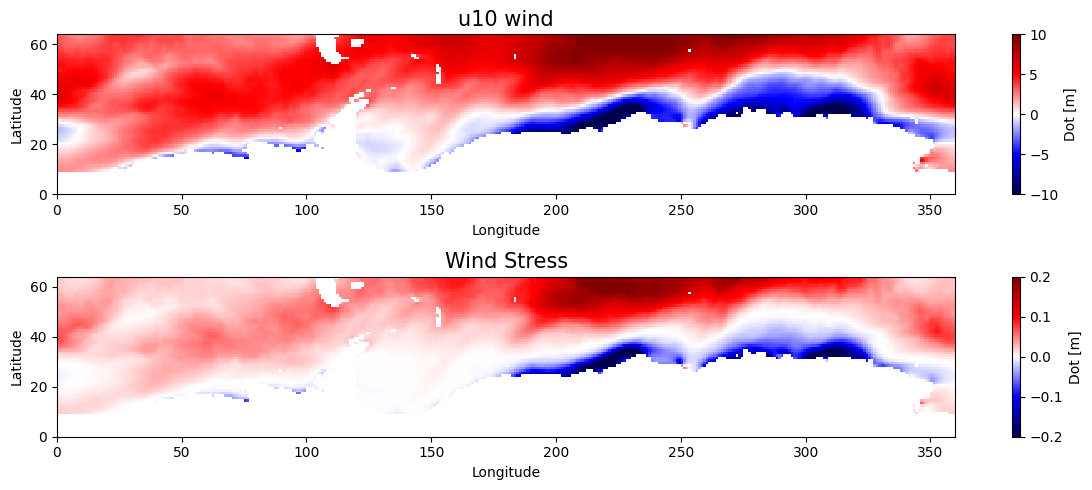

In [27]:
fig = plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
plt.pcolormesh(u10[0],cmap='seismic',vmin=-10,vmax=10)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('u10 wind', fontsize=15)
cbar1= plt.colorbar()
cbar1.set_label('Dot [m]')
plt.subplot(2,1,2)
plt.pcolormesh(tau_x[0],cmap='seismic',vmin=-0.2,vmax=0.2)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Wind Stress', fontsize=15)
cbar2= plt.colorbar()
cbar2.set_label('Dot [m]')


plt.tight_layout()


In [28]:
print(tau_x.shape)

(196, 64, 360)


In [29]:
# wind stress curl
ws_curl = np.zeros(tau_x.shape)
for t in range(0,u10.shape[0]):
    dtaux_dx, dtaux_dy = grad_sphere(tau_x[t], llon, llat)
    dtauy_dx, dtauy_dy = grad_sphere(tau_y[t], llon, llat)
    ws_curl[t] = dtauy_dx - dtaux_dy

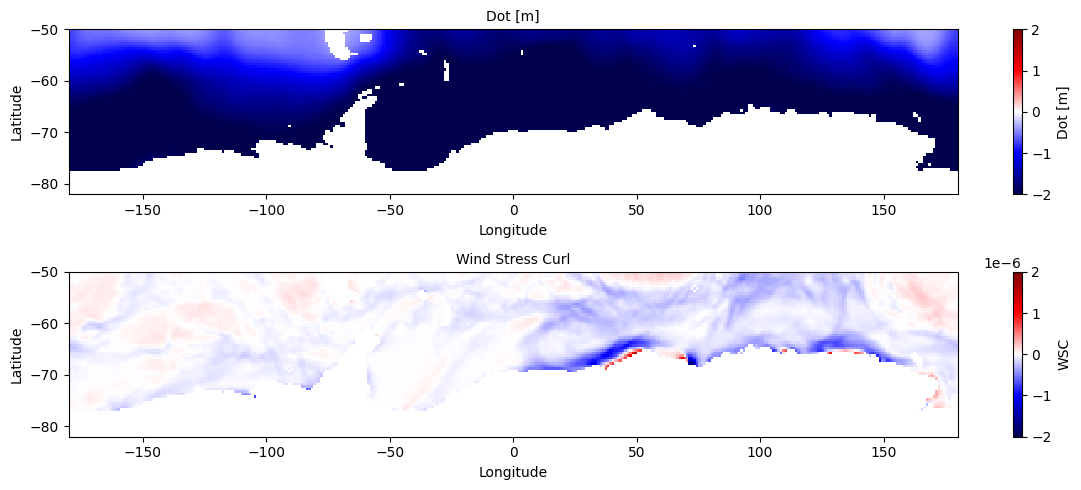

In [30]:
fig = plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
plt.pcolormesh(llon, llat, dot[0], vmin=-2, vmax=2, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Dot [m]', fontsize=10)
ws1bar = plt.colorbar()
ws1bar.set_label('Dot [m]')

plt.subplot(2,1,2)
plt.pcolormesh(llon, llat, ws_curl[0], vmin=-2e-6, vmax=2e-6, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Wind Stress Curl', fontsize=10)
#plt.quiver(llon, llat, u10[0], v10[0])
ws2bar = plt.colorbar()
ws2bar.set_label('WSC')

plt.tight_layout()

In [31]:
#create array with monthly average contribution to annual integrated (summed) NNP
ann_NPP = ds_NPP['OpenOceanNPP'].values
monthly_NPP = np.repeat(ann_NPP/12, repeats = 12, axis = 0)
print(len(ann_NPP), len(monthly_NPP))
# #select appropriate times - match to dot length/extent
# monthly_NPP = monthly_NPP[tstart_NPP:tend_NPP]
# print(len(monthly_NPP))

22 264


In [32]:
ann_NPP_ocean_masked = ds_NPP_masked['OpenOceanNPP_masked'].values
monthly_NPP_ocean_masked = np.repeat(ann_NPP_ocean_masked/12, repeats = 12, axis = 0)
print(len(ann_NPP_ocean_masked), len(monthly_NPP_ocean_masked))

22 264


In [33]:
ann_NPP_shelf_masked = ds_NPP_masked['ShelfRegionNPP_masked'].values
monthly_NPP_shelf_masked = np.repeat(ann_NPP_shelf_masked/12, repeats = 12, axis = 0)
print(len(ann_NPP_shelf_masked), len(monthly_NPP_shelf_masked))

22 264


In [34]:
print(ds_NPP.dims)
print(ds_NPP['OpenOceanNPP'].shape)
print(ann_NPP.shape)
print(monthly_NPP.shape)
print(monthly_NPP_time.shape)

FrozenMappingWarningOnValuesAccess({'lat': 480, 'lon': 4320, 'year': 22})
(22, 480, 4320)
(22, 480, 4320)
(264, 480, 4320)
(253,)


In [35]:
print(ds_NPP)

<xarray.Dataset> Size: 365MB
Dimensions:       (lat: 480, lon: 4320, year: 22)
Coordinates:
  * lat           (lat) float64 4kB -90.04 -89.96 -89.87 ... -50.21 -50.12
  * lon           (lon) float64 35kB -179.9 -179.8 -179.7 ... 179.9 180.0 180.0
  * year          (year) float64 176B 2.003e+03 2.004e+03 ... 2.024e+03
Data variables:
    OpenOceanNPP  (year, lat, lon) float64 365MB ...


In [36]:
#add monthly dates and NPP values to ds_NPP
lon_NPP = ds_NPP['lon'].values
lat_NPP = ds_NPP['lat'].values
ds_NPP['monthly_NPP']= (('monthly_NPP_time', 'lat_NPP', 'lon_NPP'), monthly_NPP[0:-11])
ds_NPP = ds_NPP.assign_coords(monthly_NPP_time = ('monthly_NPP_time', monthly_NPP_time))
ds_NPP = ds_NPP.fillna(0)

print(ds_NPP)

<xarray.Dataset> Size: 5GB
Dimensions:           (year: 22, lat: 480, lon: 4320, monthly_NPP_time: 253,
                       lat_NPP: 480, lon_NPP: 4320)
Coordinates:
  * lat               (lat) float64 4kB -90.04 -89.96 -89.87 ... -50.21 -50.12
  * lon               (lon) float64 35kB -179.9 -179.8 -179.7 ... 180.0 180.0
  * year              (year) float64 176B 2.003e+03 2.004e+03 ... 2.024e+03
  * monthly_NPP_time  (monthly_NPP_time) object 2kB '2003-01-01T00:00:00.0000...
Dimensions without coordinates: lat_NPP, lon_NPP
Data variables:
    OpenOceanNPP      (year, lat, lon) float64 365MB 0.0 0.0 0.0 ... 15.99 0.0
    monthly_NPP       (monthly_NPP_time, lat_NPP, lon_NPP) float64 4GB 0.0 .....


In [37]:
ds_NPP_masked['monthly_NPP_ocean_masked']= (('monthly_NPP_time', 'lat_NPP', 'lon_NPP'), monthly_NPP_ocean_masked[0:-11])
ds_NPP_masked['monthly_NPP_shelf_masked']= (('monthly_NPP_time', 'lat_NPP', 'lon_NPP'), monthly_NPP_shelf_masked[0:-11])
ds_NPP_masked = ds_NPP_masked.assign_coords(monthly_NPP_time = ('monthly_NPP_time', monthly_NPP_time))
ds_NPP_masked = ds_NPP_masked.fillna(0)

In [38]:
print(ds_NPP_masked)

<xarray.Dataset> Size: 9GB
Dimensions:                   (year: 22, lat: 480, lon: 4320,
                               monthly_NPP_time: 253, lat_NPP: 480,
                               lon_NPP: 4320)
Coordinates:
  * lat                       (lat) float64 4kB -90.04 -89.96 ... -50.21 -50.12
  * lon                       (lon) float64 35kB -179.9 -179.8 ... 180.0 180.0
  * year                      (year) float64 176B 2.003e+03 ... 2.024e+03
  * monthly_NPP_time          (monthly_NPP_time) object 2kB '2003-01-01T00:00...
Dimensions without coordinates: lat_NPP, lon_NPP
Data variables:
    OpenOceanNPP_masked       (year, lat, lon) float64 365MB 0.0 0.0 ... 0.0 0.0
    ShelfRegionNPP_masked     (year, lat, lon) float64 365MB 0.0 0.0 ... 0.0 0.0
    monthly_NPP_ocean_masked  (monthly_NPP_time, lat_NPP, lon_NPP) float64 4GB ...
    monthly_NPP_shelf_masked  (monthly_NPP_time, lat_NPP, lon_NPP) float64 4GB ...


In [39]:
# DE-TREND
dot.shape

(196, 64, 360)

In [40]:
# linear regression in time on each grid point
n,slope,intercept,p_val,r_square,rmse = linregress_3D(dot)
# remove trend for dot
xt = np.zeros(dot.shape)
for t in range(0,dot.shape[0]):
    xt[t] = t
dot_detrended = dot - (slope*xt + intercept)

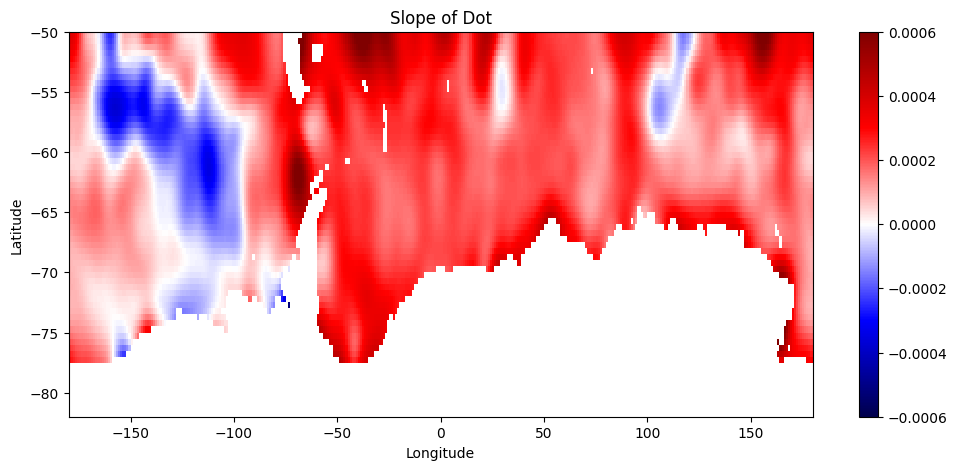

In [41]:

plt.figure(figsize=(12,5))
plt.pcolormesh(lon, lat, slope, vmin=-6e-4, vmax=6e-4, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Slope of Dot')
plt.colorbar()


In [42]:
# linear regression in time on each grid point
n,slope,intercept,p_val,r_square,rmse = linregress_3D(ws_curl)
# remove trend for ws_curl
xt = np.zeros(ws_curl.shape)
for t in range(0,ws_curl.shape[0]):
    xt[t] = t
ws_curl_detrended = ws_curl - (slope*xt + intercept)

In [43]:
#dot_final = dot_detrended.copy()
#ws_curl_final = ws_curl_detrended.copy()

In [44]:
# DE-SEASONAL

In [45]:
months = time_dot.astype('datetime64[M]').astype(int) % 12 + 1
print(months)

[ 7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10]


In [46]:
print("months shape:", months.shape)
print("ws_curl_detrended shape:", ws_curl_detrended.shape)
print('dot detreneded shape', dot_detrended.shape)

months shape: (196,)
ws_curl_detrended shape: (196, 64, 360)
dot detreneded shape (196, 64, 360)


In [47]:
# find and remove seasonality from dot_detrended and ws_curl_detrended
dot_seas = np.zeros((12,dot.shape[1],dot.shape[2])); ws_curl_seas = np.zeros((12,dot.shape[1],dot.shape[2]))
for m in range(1,13):
    dot_seas[m-1] = np.nanmean(dot_detrended[np.where(months==m)], axis=0)
    ws_curl_seas[m-1] = np.nanmean(ws_curl_detrended[np.where(months==m)], axis=0)

# remove seasonality
dot_final = np.zeros(dot_detrended.shape); ws_curl_final = np.zeros(ws_curl_detrended.shape)
for i,m in enumerate(months):
    dot_final[i] = dot_detrended[i] - dot_seas[m-1]
    ws_curl_final[i] = ws_curl_detrended[i] - ws_curl_seas[m-1]

In [48]:
print(dot.shape)
print(dot[0])
# print(dot[1])
# print(dot[2])

(196, 64, 360)
[[        nan         nan         nan ...         nan         nan
          nan]
 [        nan         nan         nan ...         nan         nan
          nan]
 [        nan         nan         nan ...         nan         nan
          nan]
 ...
 [-0.75397619 -0.73751731 -0.71145781 ... -0.71390379 -0.74343705
  -0.75675648]
 [-0.74548579 -0.72969073 -0.70308686 ... -0.69892569 -0.73085478
  -0.74653662]
 [-0.74081023 -0.72535831 -0.69847726 ... -0.69097384 -0.7240913
  -0.74097281]]


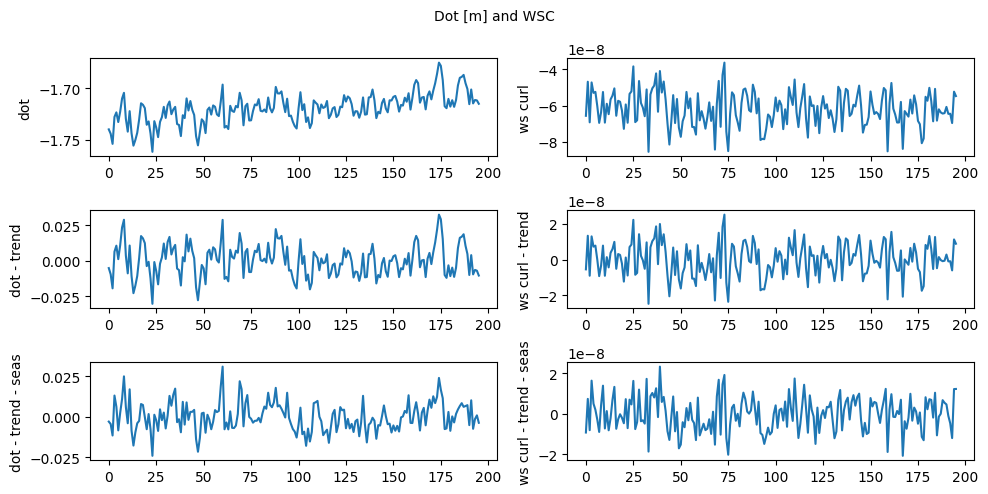

In [49]:
fig = plt.figure(figsize=(10,5))
plt.subplot(3,2,1)
plt.plot(np.nanmean(dot, axis=(1,2)))
plt.ylabel('dot')
plt.subplot(3,2,2)
plt.plot(np.nanmean(ws_curl, axis=(1,2)))
plt.ylabel('ws curl')
plt.subplot(3,2,3)
plt.plot(np.nanmean(dot_detrended, axis=(1,2)))
plt.ylabel('dot - trend')
plt.subplot(3,2,4)
plt.plot(np.nanmean(ws_curl_detrended, axis=(1,2)))
plt.ylabel('ws curl - trend')
plt.subplot(3,2,5)
plt.plot(np.nanmean(dot_final, axis=(1,2)))
plt.ylabel('dot - trend - seas')
plt.subplot(3,2,6)
plt.plot(np.nanmean(ws_curl_final, axis=(1,2)))
plt.ylabel('ws curl - trend - seas')
plt.suptitle('Dot [m] and WSC', fontsize=10)

plt.tight_layout()

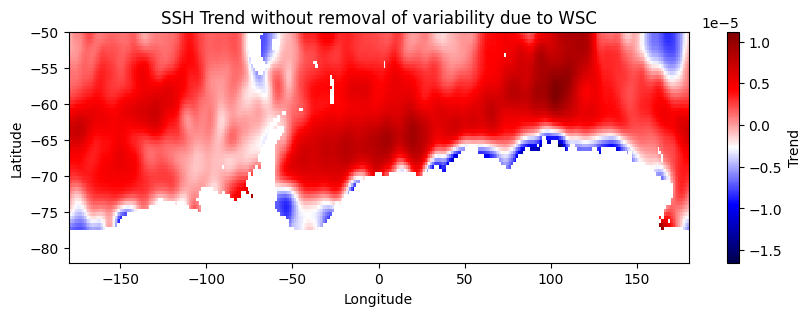

In [50]:
# SSH trends without removing ocean variability due to wind stress curl
plt.figure(figsize=(10,3))
n,slope,intercept,p_val,r_square,rmse = linregress_3D(dot_final)
plt.pcolormesh(lon, lat, slope, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('SSH Trend without removal of variability due to WSC')
cbar = plt.colorbar()
cbar.set_label('Trend')

In [51]:
print(dot_final[tstart_dot::].shape)
print(ds['latitude'].shape)
print(ds_NPP['monthly_NPP'][tstart_NPP:tend_NPP].shape)
print(ws_curl_final[6::].shape)


(190, 64, 360)
(64,)
(190, 480, 4320)
(190, 64, 360)


In [52]:
from scipy.interpolate import griddata

#regrid SSH to match NPP
ssh_data = dot_final[tstart_dot::]
source_lat = ds['latitude'].values
source_lon = ds['longitude'].values

print(source_lat.shape)
print(source_lon.shape)

source_lon2d, source_lat2d = np.meshgrid(source_lon, source_lat)
source_points = np.column_stack((source_lat2d.ravel(), source_lon2d.ravel()))

target_lat = ds_NPP['lat'].values
target_lon = ds_NPP['lon'].values

print(target_lat.shape)
print(target_lon.shape)

target_lon2d, target_lat2d = np.meshgrid(target_lon, target_lat)
target_points = np.column_stack((target_lat2d.ravel(), target_lon2d.ravel()))

num_times = ssh_data.shape[0]
regridded_ssh = np.empty((num_times, len(target_lat), len(target_lon)))

# Loop over time
for t in range(num_times):
    print(f"Regridding time step {t + 1}/{num_times}...")

    # Flatten SSH data at time t and interpolate to target grid
    values = ssh_data[t].ravel()
    interpolated = griddata(source_points, values, target_points, method='linear')

    # Reshape the interpolated values back to the target grid

    regridded_ssh[t] = interpolated.reshape((len(target_lat), len(target_lon)))


(64,)
(360,)
(480,)
(4320,)
Regridding time step 1/190...
Regridding time step 2/190...
Regridding time step 3/190...
Regridding time step 4/190...
Regridding time step 5/190...
Regridding time step 6/190...
Regridding time step 7/190...
Regridding time step 8/190...
Regridding time step 9/190...
Regridding time step 10/190...
Regridding time step 11/190...
Regridding time step 12/190...
Regridding time step 13/190...
Regridding time step 14/190...
Regridding time step 15/190...
Regridding time step 16/190...
Regridding time step 17/190...
Regridding time step 18/190...
Regridding time step 19/190...
Regridding time step 20/190...
Regridding time step 21/190...
Regridding time step 22/190...
Regridding time step 23/190...
Regridding time step 24/190...
Regridding time step 25/190...
Regridding time step 26/190...
Regridding time step 27/190...
Regridding time step 28/190...
Regridding time step 29/190...
Regridding time step 30/190...
Regridding time step 31/190...
Regridding time step

In [53]:
print(regridded_ssh.shape)
print(monthly_NPP[tstart_NPP:tend_NPP].shape)

(190, 480, 4320)
(190, 480, 4320)


In [54]:
from scipy.interpolate import griddata

#regrid SSH to match NPP
wsc_data = ws_curl_final[6::]
source_lat = ds['latitude'].values
source_lon = ds['longitude'].values

print(source_lat.shape)
print(source_lon.shape)

source_lon2d, source_lat2d = np.meshgrid(source_lon, source_lat)
source_points = np.column_stack((source_lat2d.ravel(), source_lon2d.ravel()))

target_lat = ds_NPP['lat'].values
target_lon = ds_NPP['lon'].values

print(target_lat.shape)
print(target_lon.shape)

target_lon2d, target_lat2d = np.meshgrid(target_lon, target_lat)
target_points = np.column_stack((target_lat2d.ravel(), target_lon2d.ravel()))

num_times = wsc_data.shape[0]
regridded_wsc = np.empty((num_times, len(target_lat), len(target_lon)))

# Loop over time
for t in range(num_times):
    print(f"Regridding time step {t + 1}/{num_times}...")

    # Flatten SSH data at time t and interpolate to target grid
    values = wsc_data[t].ravel()
    interpolated = griddata(source_points, values, target_points, method='linear')

    # Reshape the interpolated values back to the target grid

    regridded_wsc[t] = interpolated.reshape((len(target_lat), len(target_lon)))


(64,)
(360,)
(480,)
(4320,)
Regridding time step 1/190...
Regridding time step 2/190...
Regridding time step 3/190...
Regridding time step 4/190...
Regridding time step 5/190...
Regridding time step 6/190...
Regridding time step 7/190...
Regridding time step 8/190...
Regridding time step 9/190...
Regridding time step 10/190...
Regridding time step 11/190...
Regridding time step 12/190...
Regridding time step 13/190...
Regridding time step 14/190...
Regridding time step 15/190...
Regridding time step 16/190...
Regridding time step 17/190...
Regridding time step 18/190...
Regridding time step 19/190...
Regridding time step 20/190...
Regridding time step 21/190...
Regridding time step 22/190...
Regridding time step 23/190...
Regridding time step 24/190...
Regridding time step 25/190...
Regridding time step 26/190...
Regridding time step 27/190...
Regridding time step 28/190...
Regridding time step 29/190...
Regridding time step 30/190...
Regridding time step 31/190...
Regridding time step

In [55]:
from scipy.interpolate import griddata

#regrid oss to match NPP
oss_data = tau_eumetsat_ds['ocean_surface_stress']
oss_data = oss_data.isel(time=slice(6, None))
source_lat = tau_eumetsat_ds['lat'].values
source_lon = tau_eumetsat_ds['lon'].values

print(source_lat.shape)
print(source_lon.shape)

source_lon2d, source_lat2d = np.meshgrid(source_lon, source_lat)
source_points = np.column_stack((source_lat2d.ravel(), source_lon2d.ravel()))

target_lat = ds_NPP['lat'].values
target_lon = ds_NPP['lon'].values

print(target_lat.shape)
print(target_lon.shape)

target_lon2d, target_lat2d = np.meshgrid(target_lon, target_lat)
target_points = np.column_stack((target_lat2d.ravel(), target_lon2d.ravel()))

num_times = oss_data.shape[0]
regridded_oss = np.empty((num_times, len(target_lat), len(target_lon)))

# Loop over time
for t in range(num_times):
    print(f"Regridding time step {t + 1}/{num_times}...")

    # Flatten SSH data at time t and interpolate to target grid
    values = oss_data[t].values.ravel()
    interpolated = griddata(source_points, values, target_points, method='linear')

    # Reshape the interpolated values back to the target grid

    regridded_oss[t] = interpolated.reshape((len(target_lat), len(target_lon)))


(64,)
(360,)
(480,)
(4320,)
Regridding time step 1/190...
Regridding time step 2/190...
Regridding time step 3/190...
Regridding time step 4/190...
Regridding time step 5/190...
Regridding time step 6/190...
Regridding time step 7/190...
Regridding time step 8/190...
Regridding time step 9/190...
Regridding time step 10/190...
Regridding time step 11/190...
Regridding time step 12/190...
Regridding time step 13/190...
Regridding time step 14/190...
Regridding time step 15/190...
Regridding time step 16/190...
Regridding time step 17/190...
Regridding time step 18/190...
Regridding time step 19/190...
Regridding time step 20/190...
Regridding time step 21/190...
Regridding time step 22/190...
Regridding time step 23/190...
Regridding time step 24/190...
Regridding time step 25/190...
Regridding time step 26/190...
Regridding time step 27/190...
Regridding time step 28/190...
Regridding time step 29/190...
Regridding time step 30/190...
Regridding time step 31/190...
Regridding time step

In [56]:
from scipy.interpolate import griddata

#regrid oss to match NPP
sidc_data = sidc_eumetsat_ds['sidc']
sidc_data = sidc_data.isel(time=slice(6, None))
source_lat = sidc_eumetsat_ds['lat'].values
source_lon = sidc_eumetsat_ds['lon'].values

print(source_lat.shape)
print(source_lon.shape)

source_lon2d, source_lat2d = np.meshgrid(source_lon, source_lat)
source_points = np.column_stack((source_lat2d.ravel(), source_lon2d.ravel()))

target_lat = ds_NPP['lat'].values
target_lon = ds_NPP['lon'].values

print(target_lat.shape)
print(target_lon.shape)

target_lon2d, target_lat2d = np.meshgrid(target_lon, target_lat)
target_points = np.column_stack((target_lat2d.ravel(), target_lon2d.ravel()))

num_times = sidc_data.shape[0]
regridded_sidc = np.empty((num_times, len(target_lat), len(target_lon)))

# Loop over time
for t in range(num_times):
    print(f"Regridding time step {t + 1}/{num_times}...")

    # Flatten SSH data at time t and interpolate to target grid
    values = sidc_data[t].values.ravel()
    interpolated = griddata(source_points, values, target_points, method='linear')

    # Reshape the interpolated values back to the target grid

    regridded_sidc[t] = interpolated.reshape((len(target_lat), len(target_lon)))


(64,)
(360,)
(480,)
(4320,)
Regridding time step 1/190...
Regridding time step 2/190...
Regridding time step 3/190...
Regridding time step 4/190...
Regridding time step 5/190...
Regridding time step 6/190...
Regridding time step 7/190...
Regridding time step 8/190...
Regridding time step 9/190...
Regridding time step 10/190...
Regridding time step 11/190...
Regridding time step 12/190...
Regridding time step 13/190...
Regridding time step 14/190...
Regridding time step 15/190...
Regridding time step 16/190...
Regridding time step 17/190...
Regridding time step 18/190...
Regridding time step 19/190...
Regridding time step 20/190...
Regridding time step 21/190...
Regridding time step 22/190...
Regridding time step 23/190...
Regridding time step 24/190...
Regridding time step 25/190...
Regridding time step 26/190...
Regridding time step 27/190...
Regridding time step 28/190...
Regridding time step 29/190...
Regridding time step 30/190...
Regridding time step 31/190...
Regridding time step

In [57]:
# MCA

In [58]:
lat = ds_NPP['lat'].values
lon = ds_NPP['lon'].values

regridded_ssh = np.nan_to_num(regridded_ssh, nan=0)
selected_NPP = np.nan_to_num(monthly_NPP[tstart_NPP:tend_NPP], nan=0)
selected_NPP_ocean_masked = np.nan_to_num(monthly_NPP_ocean_masked[tstart_NPP:tend_NPP], nan=0)
selected_NPP_shelf_masked = np.nan_to_num(monthly_NPP_shelf_masked[tstart_NPP:tend_NPP], nan=0)
regridded_wsc = np.nan_to_num(regridded_wsc, nan=0)
regridded_sidc = np.nan_to_num(regridded_sidc, nan=0)
regridded_oss = np.nan_to_num(regridded_oss, nan=0)

dot_xa = xr.DataArray(regridded_ssh, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
ws_curl_xa = xr.DataArray(regridded_wsc, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
NPP_xa = xr.DataArray(selected_NPP, coords = [time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
NPP_ocean_masked_xa = xr.DataArray(selected_NPP_ocean_masked, coords = [time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
NPP_shelf_masked_xa = xr.DataArray(selected_NPP_shelf_masked, coords = [time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
oss_xa = xr.DataArray(regridded_oss, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)
sidc_xa = xr.DataArray(regridded_sidc, coords=[time_dot[tstart_dot::], lat, lon], dims=["time", "lon", "lat"],)

In [59]:
total_nans = dot_xa.isnull().sum().item()
print(f"Total NaN values in dot_xa: {total_nans}")
total_points_dot = dot_xa.size
print(f"Total data points in dot_xa: {total_points_dot}")

total_nans_wsc = ws_curl_xa.isnull().sum().item()
print(f"Total NaN values in wsc: {total_nans_wsc}")
total_points_wsc = ws_curl_xa.size
print(f"Total data points in wsc: {total_points_wsc}")

total_nans_oss = oss_xa.isnull().sum().item()
print(f"Total NaN values in oss: {total_nans_oss}")
total_points_oss = oss_xa.size
print(f"Total data points in oss: {total_points_oss}")

total_nans_sidc = sidc_xa.isnull().sum().item()
print(f"Total NaN values in sidc: {total_nans_sidc}")
total_points_sidc = sidc_xa.size
print(f"Total data points in sidc: {total_points_sidc}")

total_nans_NPP = NPP_xa.isnull().sum().item()
print(f"Total NaN values in NPP_xa: {total_nans_NPP}")
total_points_NPP = NPP_xa.size
print(f"Total data points in NPP_xa: {total_points_NPP}")

total_nans_NPP_ocean = NPP_ocean_masked_xa.isnull().sum().item()
print(f"Total NaN values in NPP_ocean_masked_xa: {total_nans_NPP_ocean}")
total_points_NPP_ocean = NPP_ocean_masked_xa.size
print(f"Total data points in NPP_ocean_masked_xa: {total_points_NPP_ocean}")

total_nans_NPP_shelf = NPP_shelf_masked_xa.isnull().sum().item()
print(f"Total NaN values in NPP_shelf_masked_xa: {total_nans_NPP_shelf}")
total_points_NPP_shelf = NPP_shelf_masked_xa.size
print(f"Total data points in NPP_ocea_masked_xa: {total_points_NPP_shelf}")

Total NaN values in dot_xa: 0
Total data points in dot_xa: 393984000
Total NaN values in wsc: 0
Total data points in wsc: 393984000
Total NaN values in oss: 0
Total data points in oss: 393984000
Total NaN values in sidc: 0
Total data points in sidc: 393984000
Total NaN values in NPP_xa: 0
Total data points in NPP_xa: 393984000
Total NaN values in NPP_ocean_masked_xa: 0
Total data points in NPP_ocean_masked_xa: 393984000
Total NaN values in NPP_shelf_masked_xa: 0
Total data points in NPP_ocea_masked_xa: 393984000


In [60]:
print(dir(xe))


['RotatorFactory', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_version', 'base_model', 'cross', 'data_container', 'linalg', 'multi', 'preprocessing', 'rotator_factory', 'single', 'utils', 'validation']


In [61]:
import inspect
model = xe.cross.MCA(n_modes=15, standardize=True)
#print(dir(model))

print(dot_xa.coords)

print(dir(model))
print(dot_xa.dims)
#print(ws_curl_xa.dims)
model.fit(dot_xa, ws_curl_xa, dim='time')

#model.fit(dot_xa, NPP_xa, dim='time')
#model.fit(ws_curl_xa, NPP_xa, dim='time')
#model.fit(oss_xa, NPP_xa, dim='time')
#model.fit(sidc_xa, NPP_xa, dim='time')
#model.fit(sidc_xa, NPP_xa, dim='time')



comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)

Coordinates:
  * time     (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2018-10-01
  * lon      (lon) float64 4kB -90.04 -89.96 -89.87 ... -50.29 -50.21 -50.12
  * lat      (lat) float64 35kB -179.9 -179.8 -179.7 ... 179.9 180.0 180.0
['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_augment_data', '_check_parameter_number', '_compute_cross_covariance_diagonal_numpy', '_compute_cross_covariance_numpy', '_compute_cross_matrix', '_compute_total_squared_covariance', '_compute_total_variance', '_covariance_explained_DC95', '_decomposer_kwargs', '_deserialize_attrs', '_fit_algorithm', '_get_components', '_get_scores', '_inverse_t

In [62]:
s1 = scores1.values; s2 = scores2.values
c1 = comps1.values; c2 = comps2.values

In [63]:
print(path)
print(gridtype)

/Users/iw2g24/PycharmProjects/SSH_project/
remapcon


In [64]:
# Full path to the 'results' directory
results_dir = os.path.join(path, 'results')

# Check if the directory already exists
if os.path.exists(results_dir):
    print("Directory already exists")
else:
    # Create the directory if it doesn't exist
    os.makedirs(results_dir, exist_ok=True)
    print("Directory created!")

Directory already exists


In [65]:
# # write PCs on files
# # fname = path + 'results/PCs_dot_' + gridtype + '.txt'
# fname = path + 'results/PCs_dot_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(time_dot)):
#         file.write(f'{time_dot[i]}\t{s1[0,i]}\t{s1[1,i]}\t{s1[2,i]}\n')
# file.close()
#
# # fname = path + 'results/PCs_ws_curl_' + gridtype + '.txt'
# fname = path + 'results/PCs_ws_curl_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(time_dot)):
#         file.write(f'{time_dot[i]}\t{s2[0,i]}\t{s2[1,i]}\t{s2[2,i]}\n')
# file.close()

In [66]:
#how can you change from using cross.MCA to calling the subplots PCA1, PCA2, PCA3 etc ...

In [67]:
r_pears = []; p_pears = []
r_spear = []; p_spear = []
for m in range(1,5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2)); p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2)); p_spear.append(np.round(p, 2))

In [68]:
# compute squared covariance fraction (equivalent to explained variance in PCA)
sq_cov_frac = model.squared_covariance_fraction()
scf = sq_cov_frac.values
cum_sum = np.cumsum(scf)
print('Cumulative sum of squares:', cum_sum)
print('Squared covariance fraction:',scf)

Cumulative sum of squares: [0.47833384 0.67151627 0.74260452 0.79693178 0.84237129 0.87597158
 0.89928486 0.91665912 0.92946561 0.94063436 0.95014999 0.95697879
 0.9617647  0.96619194 0.97003765]
Squared covariance fraction: [0.47833384 0.19318243 0.07108824 0.05432726 0.04543952 0.03360029
 0.02331328 0.01737426 0.01280649 0.01116875 0.00951563 0.0068288
 0.00478591 0.00442724 0.00384571]


In [69]:
print(type(cum_sum))
print(len(cum_sum))
mode_percent = []
for i in range(len(cum_sum)):
    if i == 0:
        each_mode_percent =float(cum_sum[i])
        mode_percent.append(each_mode_percent)
    else:
        each_mode_percent = float(cum_sum[i]-cum_sum[i-1])
        mode_percent.append(each_mode_percent)
print('PCA fraction', mode_percent)

<class 'numpy.ndarray'>
15
PCA fraction [0.47833384339822205, 0.19318242799668484, 0.0710882438215491, 0.05432726216550832, 0.0454395155204127, 0.033600289692097496, 0.023313278075693833, 0.01737425878327059, 0.0128064893477291, 0.011168753690557698, 0.009515627348134048, 0.006828800174855654, 0.004785913247901008, 0.0044272381755274814, 0.003845708742360787]


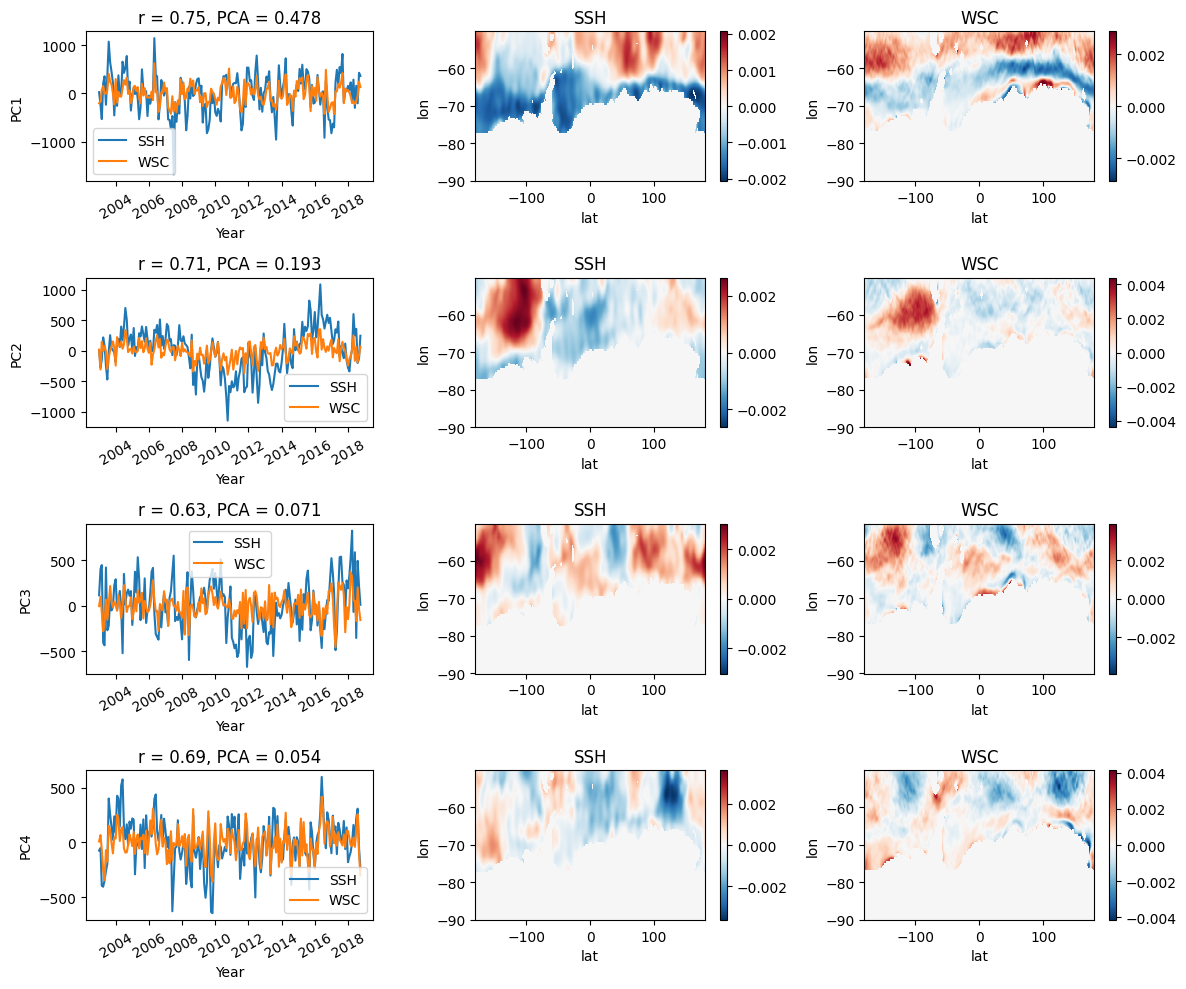

In [70]:
fig = plt.figure(figsize=(12,10))

for i in range(0,4):
    j = 3*i+1 # a = 2*(i+1) + i - 1
    
    plt.subplot(4,3,j)
    scores1.sel(mode=i+1).plot(label = 'SSH')
    scores2.sel(mode=i+1).plot(label = 'WSC')
    plt.title("r = {}, PCA = {:.3f}".format(r_spear[i], mode_percent[i]))
    plt.xlabel('Year'); plt.ylabel('PC'+str(int(i+1)))
    plt.xticks(rotation=30) 
    plt.legend()
    
    plt.subplot(4,3,j+1)
    comps1.sel(mode=i+1).plot()
    plt.title('SSH')
    
    plt.subplot(4,3,j+2)
    comps2.sel(mode=i+1).plot()
    plt.title('WSC')

fig.tight_layout()

# fig.savefig(path + 'results/MCA_output_' + gridtype + '_seas.png')

In [71]:
#save the figure
#fig.savefig(fig_path + 'ssh_wsc_rect3_NPP2.png')

In [72]:
#

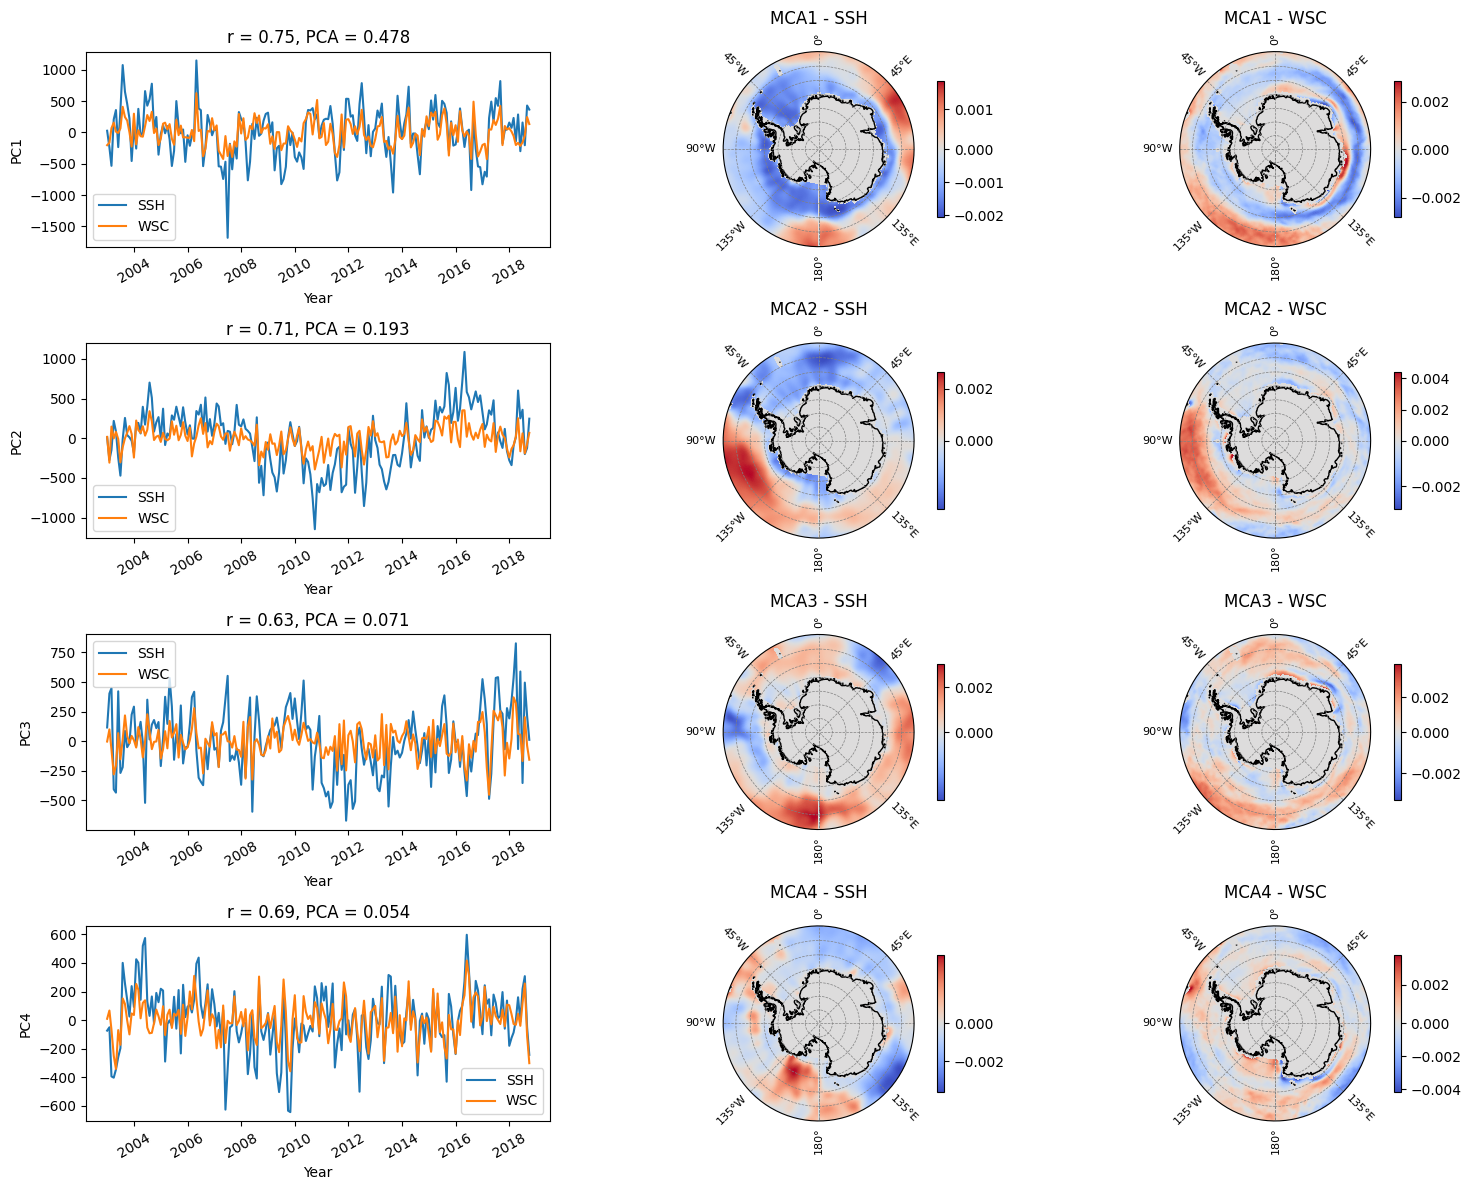

In [73]:
from polar_plot_utils import plot_curvilinear_data
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import colors
import scipy.stats
from matplotlib.gridspec import GridSpec

# Assuming comps1 and comps2 are already defined (MCA components)
comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
s1 = scores1.values
s2 = scores2.values
c1 = comps1.values
c2 = comps2.values


# Initialize lists for correlation coefficients
r_pears = []
p_pears = []
r_spear = []
p_spear = []

# Calculate correlation coefficients
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2))
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2))
    p_spear.append(np.round(p, 2))

# Create the figure and GridSpec
fig = plt.figure(figsize=(15, 12))  # Adjust figure size to accommodate bigger columns
gs = GridSpec(4, 3, figure=fig, width_ratios=[2, 2, 2])  # Column widths: 1 for column 1, 2 for columns 2 and 3

# Loop over modes 1 to 4 and plot results
for i in range(0, 4):
    j = 3 * i  # Column position for scores plots

    # Plot scores (time series) in 1st column
    ax1 = fig.add_subplot(gs[i, 0])  # Use gs to position the subplot in the 1st column
    scores1.sel(mode=i + 1).plot(ax=ax1, label='SSH')
    scores2.sel(mode=i + 1).plot(ax=ax1, label='WSC')
    ax1.set_title("r = {}, PCA = {:.3f}".format(r_spear[i], mode_percent[i]))
    ax1.set_xlabel('Year')
    ax1.set_ylabel('PC' + str(int(i + 1)))
    ax1.tick_params(axis='x', rotation=30)
    ax1.legend()

    # Create circular plot for SSH in 2nd column
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.SouthPolarStereo())  # 2nd column (bigger)
    comp1 = comps1.sel(mode=i + 1)
    lon = comp1.lat.values
    lat = comp1.lon.values
    data1 = comp1.values
    plot_curvilinear_data(ax2, data1,lon, lat, "MCA" + str(i + 1) + " - SSH")

    # Create circular plot for WSC in 3rd column
    ax3 = fig.add_subplot(gs[i, 2], projection=ccrs.SouthPolarStereo())  # 3rd column (bigger)
    comp2 = comps2.sel(mode=i + 1)
    data2 = comp2.values
    plot_curvilinear_data(ax3, data2, lon,lat, "MCA" + str(i + 1) + " - WSC")

# Adjust layout to prevent overlap
fig.tight_layout()
plt.show()


In [74]:
#save the figure
#fig.savefig(fig_path + 'ssh_wsc_curvi4_NPP2.png')

In [75]:
# raise SystemExit("End of section — stopping execution here")

Coordinates:
  * time     (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2018-10-01
  * lon      (lon) float64 4kB -90.04 -89.96 -89.87 ... -50.29 -50.21 -50.12
  * lat      (lat) float64 35kB -179.9 -179.8 -179.7 ... 179.9 180.0 180.0
['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_augment_data', '_check_parameter_number', '_compute_cross_covariance_diagonal_numpy', '_compute_cross_covariance_numpy', '_compute_cross_matrix', '_compute_total_squared_covariance', '_compute_total_variance', '_covariance_explained_DC95', '_decomposer_kwargs', '_deserialize_attrs', '_fit_algorithm', '_get_components', '_get_scores', '_inverse_t

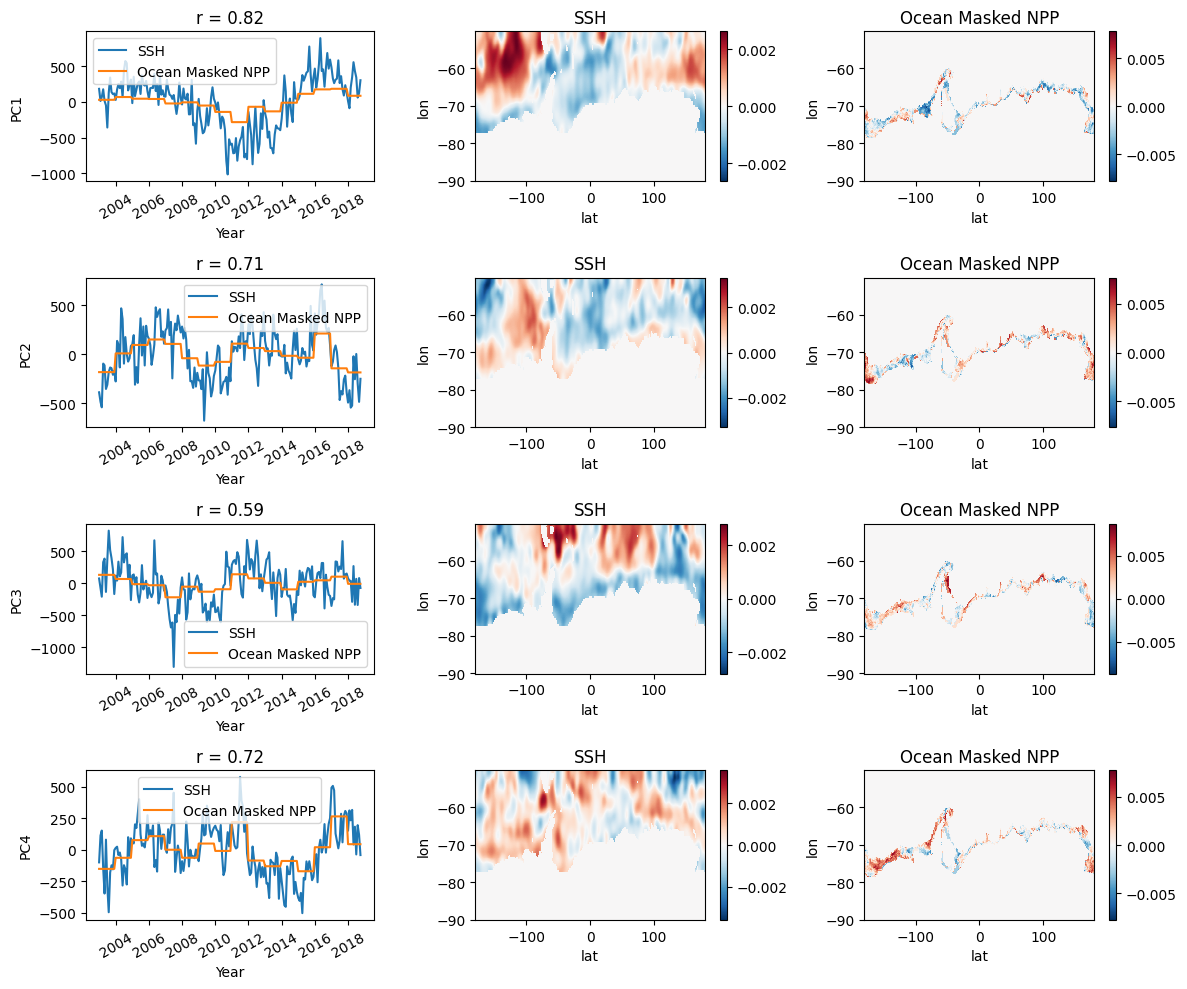

In [76]:
import inspect

model = xe.cross.MCA(n_modes=15, standardize=True)
#print(dir(model))

print(ws_curl_xa.coords)

print(dir(model))
print(ws_curl_xa.dims)
#print(ws_curl_xa.dims)
# model.fit(dot_xa, ws_curl_xa, dim='time')
#model.fit(ws_curl_xa, NPP_xa, dim='time')
model.fit(dot_xa, NPP_ocean_masked_xa, dim='time')
comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
s1 = scores1.values;
s2 = scores2.values
c1 = comps1.values;
c2 = comps2.values
print(path)
print(gridtype)
# Full path to the 'results' directory
results_dir = os.path.join(path, 'results')

# Check if the directory already exists
if os.path.exists(results_dir):
    print("Directory already exists")
else:
    # Create the directory if it doesn't exist
    os.makedirs(results_dir, exist_ok=True)
    print("Directory created!")
# # write PCs on files
# # fname = path + 'results/PCs_dot_' + gridtype + '.txt'
# fname = path + 'results/PCs_dot_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(time_dot)):
#         file.write(f'{time_dot[i]}\t{s1[0,i]}\t{s1[1,i]}\t{s1[2,i]}\n')
# file.close()
#
# # fname = path + 'results/PCs_ws_curl_' + gridtype + '.txt'
# fname = path + 'results/PCs_ws_curl_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(time_dot)):
#         file.write(f'{time_dot[i]}\t{s2[0,i]}\t{s2[1,i]}\t{s2[2,i]}\n')
# file.close()
#how can you change from using cross.MCA to calling the subplots PCA1, PCA2, PCA3 etc ...
r_pears = [];
p_pears = []
r_spear = [];
p_spear = []
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2));
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2));
    p_spear.append(np.round(p, 2))
fig = plt.figure(figsize=(12, 10))

for i in range(0, 4):
    j = 3 * i + 1  # a = 2*(i+1) + i - 1

    plt.subplot(4, 3, j)
    scores1.sel(mode=i + 1).plot(label='SSH')
    scores2.sel(mode=i + 1).plot(label='Ocean Masked NPP')
    plt.title('r = ' + str(r_spear[i]))
    plt.xlabel('Year');
    plt.ylabel('PC' + str(int(i + 1)))
    plt.xticks(rotation=30)
    plt.legend()

    plt.subplot(4, 3, j + 1)
    comps1.sel(mode=i + 1).plot()
    plt.title('SSH')

    plt.subplot(4, 3, j + 2)
    comps2.sel(mode=i + 1).plot()
    plt.title('Ocean Masked NPP')

fig.tight_layout()

# fig.savefig(path + 'results/MCA_output_' + gridtype + '_seas.png')
# compute squared covariance fraction (equivalent to explained variance in PCA)
sq_cov_frac = model.squared_covariance_fraction()
scf = sq_cov_frac.values
cum_sum = np.cumsum(scf)
print('Cumulative sum of squares:', cum_sum)
print('Squared covariance fraction:', scf)
print(type(cum_sum))
print(len(cum_sum))
mode_percent = []
for i in range(len(cum_sum)):
    if i == 0:
        each_mode_percent = float(cum_sum[i])
        mode_percent.append(each_mode_percent)
    else:
        each_mode_percent = float(cum_sum[i] - cum_sum[i - 1])
        mode_percent.append(each_mode_percent)
print('PCA fraction', mode_percent)


(480, 4320)
(4320,)
(480,)


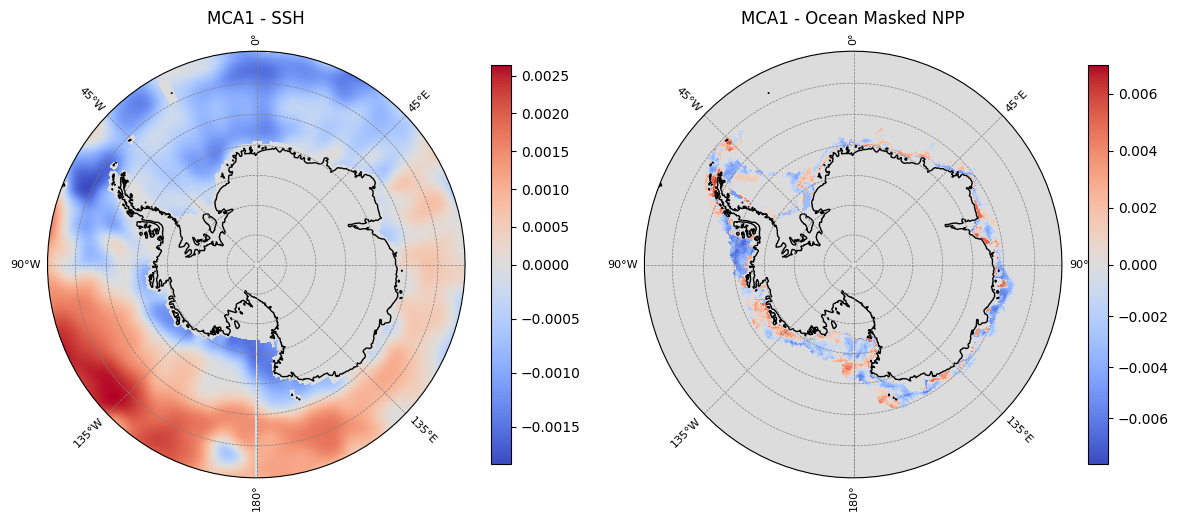

In [77]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import colors
from polar_plot_utils import plot_curvilinear_data

# Assuming comps1 and comps2 are already defined and contain your data
comp1 = comps1.sel(mode=1)
comp2 = comps2.sel(mode=1)
lon = comp1.lat.values
lat = comp1.lon.values
data1 = comp1.values
data2 = comp2.values


print(data1.shape)
print(lon.shape)
print(lat.shape)
# Create figure and axes for two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={'projection': ccrs.SouthPolarStereo()})

# Plot data1 (Left subplot)
pc1 = plot_curvilinear_data(axes[0], data1,lon, lat, "MCA1 - SSH")

# Plot data2 (Right subplot)
pc2 = plot_curvilinear_data(axes[1], data2, lon, lat, "MCA1 - Ocean Masked NPP")

# Add colorbars for both subplots
# fig.colorbar(pc1, ax=axes[0], orientation='vertical', label='Amplitude', shrink=0.7, pad=0.05)
# fig.colorbar(pc2, ax=axes[1], orientation='vertical', label='Amplitude', shrink=0.7, pad=0.05)

plt.tight_layout()
plt.show()


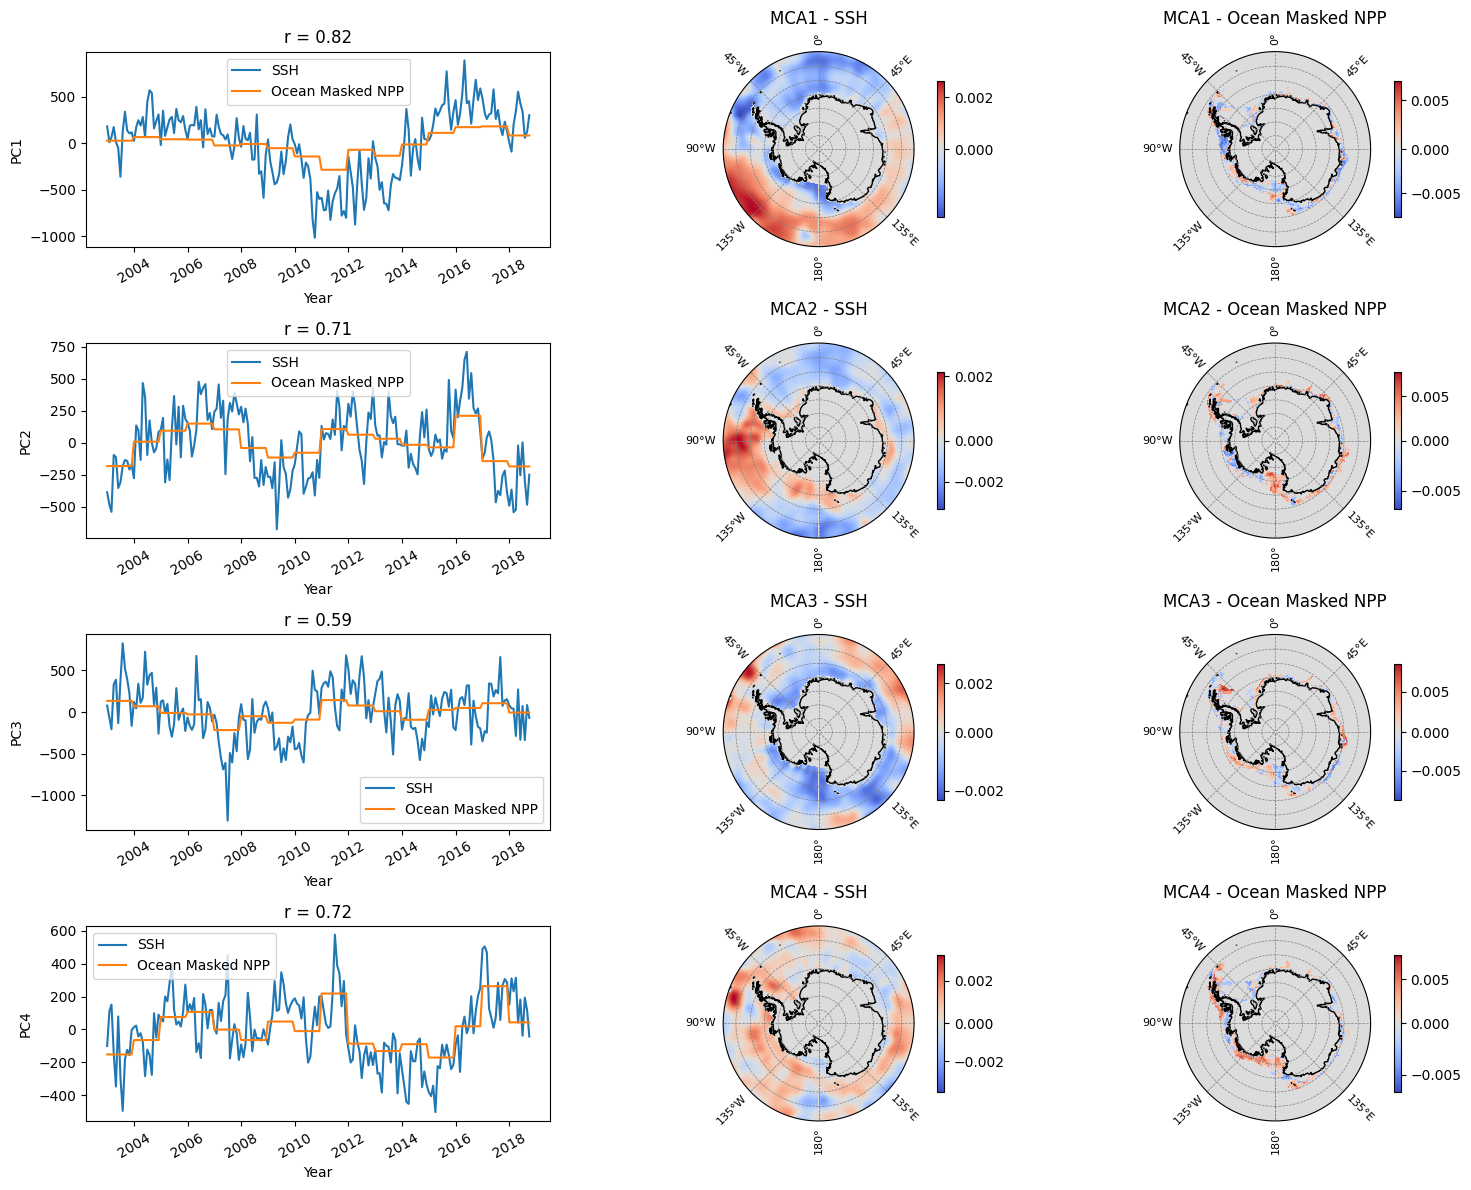

In [78]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import colors
import scipy.stats
from matplotlib.gridspec import GridSpec

# Assuming comps1 and comps2 are already defined (MCA components)
comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
s1 = scores1.values
s2 = scores2.values
c1 = comps1.values
c2 = comps2.values


# Initialize lists for correlation coefficients
r_pears = []
p_pears = []
r_spear = []
p_spear = []

# Calculate correlation coefficients
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2))
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2))
    p_spear.append(np.round(p, 2))

# Create the figure and GridSpec
fig = plt.figure(figsize=(15, 12))  # Adjust figure size to accommodate bigger columns
gs = GridSpec(4, 3, figure=fig, width_ratios=[2, 2, 2])  # Column widths: 1 for column 1, 2 for columns 2 and 3

# Loop over modes 1 to 4 and plot results
for i in range(0, 4):
    j = 3 * i  # Column position for scores plots

    # Plot scores (time series) in 1st column
    ax1 = fig.add_subplot(gs[i, 0])  # Use gs to position the subplot in the 1st column
    scores1.sel(mode=i + 1).plot(ax=ax1, label='SSH')
    scores2.sel(mode=i + 1).plot(ax=ax1, label='Ocean Masked NPP')
    ax1.set_title('r = ' + str(r_spear[i]))
    ax1.set_xlabel('Year')
    ax1.set_ylabel('PC' + str(int(i + 1)))
    ax1.tick_params(axis='x', rotation=30)
    ax1.legend()

    # Create circular plot for SSH in 2nd column
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.SouthPolarStereo())  # 2nd column (bigger)
    comp1 = comps1.sel(mode=i + 1)
    lon = comp1.lat.values
    lat = comp1.lon.values
    data1 = comp1.values
    plot_curvilinear_data(ax2, data1,lon, lat, "MCA" + str(i + 1) + " - SSH")

    # Create circular plot for WSC in 3rd column
    ax3 = fig.add_subplot(gs[i, 2], projection=ccrs.SouthPolarStereo())  # 3rd column (bigger)
    comp2 = comps2.sel(mode=i + 1)
    data2 = comp2.values
    plot_curvilinear_data(ax3, data2, lon,lat, "MCA" + str(i + 1) + " - Ocean Masked NPP")

# Adjust layout to prevent overlap
fig.tight_layout()
plt.show()


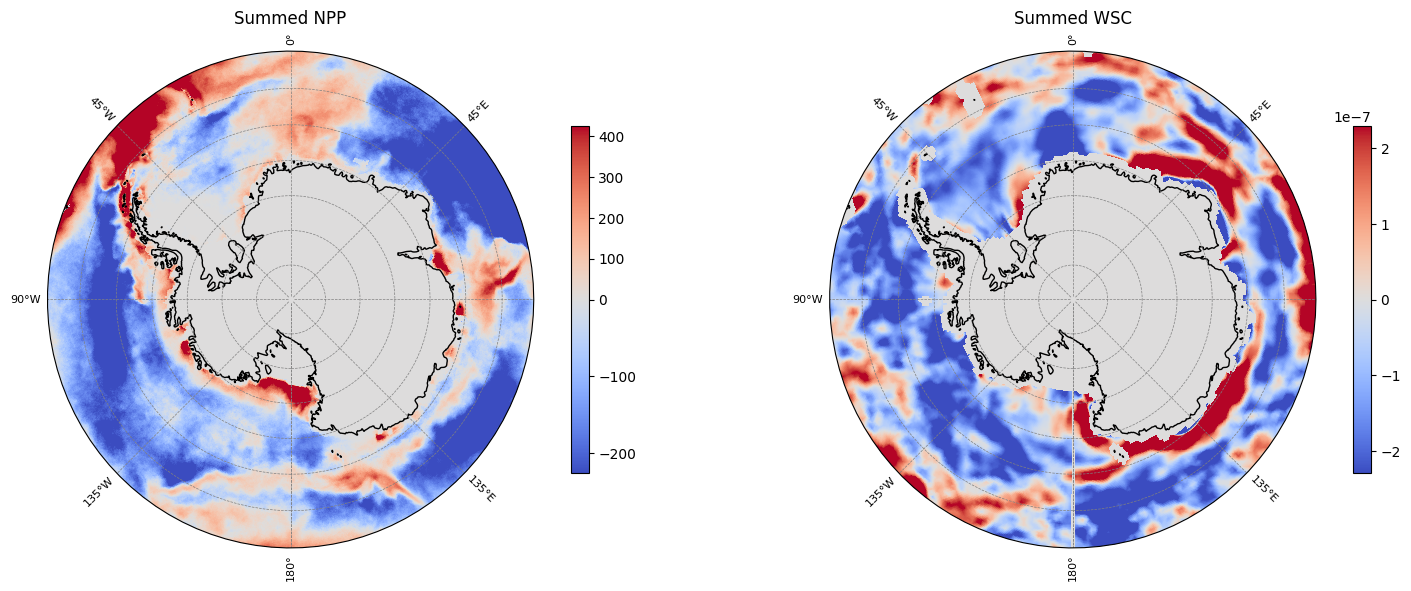

In [79]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Compute vmin/vmax for each variable
sum_NPP = ds_NPP['OpenOceanNPP'].sum(dim=['year'])
vmin_npp = np.percentile(sum_NPP, 5)
vmax_npp = np.percentile(sum_NPP, 95)

sum_WSC = ws_curl_xa.sum(dim=['time'])
vmin_wsc = np.percentile(sum_WSC, 5)
vmax_wsc = np.percentile(sum_WSC, 95)

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6),
                         subplot_kw={'projection': ccrs.SouthPolarStereo()})

# First subplot: Summed NPP
plot_curvilinear_data(axes[0], sum_NPP, lon, lat, "Summed NPP", vmin=vmin_npp, vmax=vmax_npp)

# Second subplot: Summed WSC
plot_curvilinear_data(axes[1], sum_WSC, lon, lat, "Summed WSC", vmin=vmin_wsc, vmax=vmax_wsc)

plt.tight_layout()
plt.show()


In [80]:
print(len(ws_curl_xa['time']))

190


In [81]:
## TIME LAG CROSS - CORRELATION

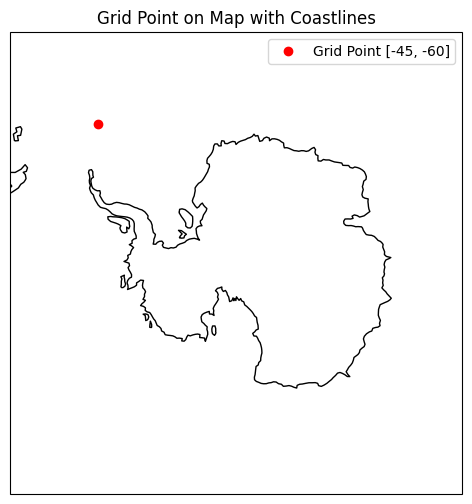

In [82]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Assume lon and lat are 2D arrays with shape (ny, nx)
# Replace this with your actual longitude/latitude arrays
# lon = ds['lon'].values
# lat = ds['lat'].values

# Example: Grid index you want to plot

lon_pt = -45
lat_pt = -60

# Create the figure with a map projection
fig, ax = plt.subplots(figsize=(6, 6),
                       subplot_kw={'projection': ccrs.SouthPolarStereo()})

# Add coastlines
ax.coastlines(resolution='110m')

# Set extent (adjust as needed)
ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())

# Plot the grid point
ax.plot(lon_pt, lat_pt, 'ro', markersize=6,
        transform=ccrs.PlateCarree(), label=f'Grid Point [{lon_pt}, {lat_pt}]')

# Add a legend
ax.legend()
ax.set_title("Grid Point on Map with Coastlines")

plt.show()


In [83]:
import numpy as np

lon = ws_curl_xa['lon'].values  # shape (nx,)
lat = ws_curl_xa['lat'].values  # shape (ny,)

# Find closest index along lon and lat axes
j = np.abs(lon - lon_pt).argmin()
i = np.abs(lat - lat_pt).argmin()

print(f"Closest grid point indices: i={i}, j={j}")
print(f"Grid point lon/lat: ({lon[j]}, {lat[i]})")


Closest grid point indices: i=1439, j=479
Grid point lon/lat: (-50.12499999999998, -59.958333333333336)


In [84]:
# print('hello this is a deliberate error')
# raise SystemExit("Stopping notebook here to avoid running unsafe code.")

In [85]:
path = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'
ice_vels_ds = xr.open_dataset(path+ 'NSIDC-0792_19920317-20171216_V01.0.nc')
print(ice_vels_ds['time'].values)


['1992-03-17T03:04:19.200002304' '1992-06-16T15:04:19.200002304'
 '1992-09-16T03:04:19.200002304' '1992-12-16T15:04:19.200002304'
 '1993-03-17T22:04:48.000003584' '1993-06-17T04:04:48.000003584'
 '1993-09-16T10:04:48.000003584' '1993-12-16T16:04:48.000003584'
 '1994-03-17T22:04:48.000003584' '1994-06-17T04:04:48.000003584'
 '1994-09-16T10:04:48.000003584' '1994-12-16T16:04:48.000003584'
 '1995-03-17T22:04:48.000003584' '1995-06-17T04:04:48.000003584'
 '1995-09-16T10:04:48.000003584' '1995-12-16T16:04:48.000003584'
 '1996-03-17T03:04:19.200002304' '1996-06-16T15:04:19.200002304'
 '1996-09-16T03:04:19.200002304' '1996-12-16T15:04:19.200002304'
 '1997-03-17T22:04:48.000003584' '1997-06-17T04:04:48.000003584'
 '1997-09-16T10:04:48.000003584' '1997-12-16T16:04:48.000003584'
 '1998-03-17T22:04:48.000003584' '1998-06-17T04:04:48.000003584'
 '1998-09-16T10:04:48.000003584' '1998-12-16T16:04:48.000003584'
 '1999-03-17T22:04:48.000003584' '1999-06-17T04:04:48.000003584'
 '1999-09-16T10:04:48.000

In [86]:
x = ice_vels_ds['x'].values  # Get NumPy array of x coordinates
y = ice_vels_ds['y'].values  # Get NumPy array of y coordinates

# Create a 2D grid of x and y coordinates
X, Y = np.meshgrid(x, y)

# Define the stereographic projection (SH)
proj_stere = Proj("+proj=stere +lat_0=-90 +lat_ts=-70 +lon_0=0 +k=1 +x_0=0 +y_0=0 +a=6378273 +b=6356889.449 +units=m +no_defs")

# Define target WGS84 projection
proj_wgs84 = Proj("epsg:4326")

# Use Transformer for efficient vectorized transformation
transformer = Transformer.from_proj(proj_stere, proj_wgs84, always_xy=True)

# Convert entire 2D grid of (X, Y) to (lon, lat)
lon, lat = transformer.transform(X, Y)

# Add lat/lon to dataset
ice_vels_ds.coords['lon'] = (('x', 'y'), lon)
ice_vels_ds.coords['lat'] = (('x', 'y'), lat)

In [87]:
# Assuming masked_melt['time'] is a pandas DatetimeIndex or numpy datetime64 array
times = pd.to_datetime(ice_vels_ds['time'].values)  # Convert to pandas datetime if it's not already

# Format to YYYY-MM-01THH:MM:SS., explicitly set day to '01' in the string
formatted_times = times.strftime('%Y-%m-01T00:00:00.000000000')

# Extract nanoseconds directly from pandas Timestamps using .nanosecond
#nanoseconds = masked_melt_times.nanosecond.astype(str).str.zfill(9)

# Combine the formatted time with the nanoseconds to preserve nanosecond precision
formatted_times_with_nano = formatted_times

# Update the 'time' field in masked_melt with the newly formatted time strings
ice_vels_ds['time'] = formatted_times_with_nano

# Print the updated time values
print(len(ice_vels_ds['time']))
print(ice_vels_ds['time'][44], ice_vels_ds['time'][-1])

104
<xarray.DataArray 'time' ()> Size: 116B
array('2003-03-01T00:00:00.000000000', dtype='<U29')
Coordinates:
    time     <U29 116B '2003-03-01T00:00:00.000000000' <xarray.DataArray 'time' ()> Size: 116B
array('2017-12-01T00:00:00.000000000', dtype='<U29')
Coordinates:
    time     <U29 116B '2017-12-01T00:00:00.000000000'


In [88]:
print(ds_NPP_masked)

<xarray.Dataset> Size: 9GB
Dimensions:                   (year: 22, lat: 480, lon: 4320,
                               monthly_NPP_time: 253, lat_NPP: 480,
                               lon_NPP: 4320)
Coordinates:
  * lat                       (lat) float64 4kB -90.04 -89.96 ... -50.21 -50.12
  * lon                       (lon) float64 35kB -179.9 -179.8 ... 180.0 180.0
  * year                      (year) float64 176B 2.003e+03 ... 2.024e+03
  * monthly_NPP_time          (monthly_NPP_time) object 2kB '2003-01-01T00:00...
Dimensions without coordinates: lat_NPP, lon_NPP
Data variables:
    OpenOceanNPP_masked       (year, lat, lon) float64 365MB 0.0 0.0 ... 0.0 0.0
    ShelfRegionNPP_masked     (year, lat, lon) float64 365MB 0.0 0.0 ... 0.0 0.0
    monthly_NPP_ocean_masked  (monthly_NPP_time, lat_NPP, lon_NPP) float64 4GB ...
    monthly_NPP_shelf_masked  (monthly_NPP_time, lat_NPP, lon_NPP) float64 4GB ...


In [89]:
#create new NPP dates where they are quarterly (not annual)
start_year = int(time_NPP[0])
end_year = int(time_NPP[-1])
quarterly_NPP_time = pd.date_range(start=f'{start_year}',end=f'{end_year}', freq='Q')
quarterly_NPP_time = quarterly_NPP_time.strftime('%Y-%m-%dT%H:%M:%S.%f000')
print(len(quarterly_NPP_time))
print(quarterly_NPP_time[0], quarterly_NPP_time[59])
print(quarterly_NPP_time.dtype)

84
2003-03-31T00:00:00.000000000 2017-12-31T00:00:00.000000000
object


In [90]:
#create array with monthly average contribution to annual integrated (summed) NNP
ann_NPP = ds_NPP['OpenOceanNPP'].values
quarterly_NPP = np.repeat(ann_NPP / 4, repeats=4, axis=0)
print(len(ann_NPP), len(quarterly_NPP))
print(quarterly_NPP_time.dtype)

# #select appropriate times - match to dot length/extent
quarterly_NPP = quarterly_NPP[0:59]
quarterly_NPP_time = quarterly_NPP_time[0:59]
print(quarterly_NPP_time.dtype)
print(quarterly_NPP_time)


22 88
object
object
Index(['2003-03-31T00:00:00.000000000', '2003-06-30T00:00:00.000000000',
       '2003-09-30T00:00:00.000000000', '2003-12-31T00:00:00.000000000',
       '2004-03-31T00:00:00.000000000', '2004-06-30T00:00:00.000000000',
       '2004-09-30T00:00:00.000000000', '2004-12-31T00:00:00.000000000',
       '2005-03-31T00:00:00.000000000', '2005-06-30T00:00:00.000000000',
       '2005-09-30T00:00:00.000000000', '2005-12-31T00:00:00.000000000',
       '2006-03-31T00:00:00.000000000', '2006-06-30T00:00:00.000000000',
       '2006-09-30T00:00:00.000000000', '2006-12-31T00:00:00.000000000',
       '2007-03-31T00:00:00.000000000', '2007-06-30T00:00:00.000000000',
       '2007-09-30T00:00:00.000000000', '2007-12-31T00:00:00.000000000',
       '2008-03-31T00:00:00.000000000', '2008-06-30T00:00:00.000000000',
       '2008-09-30T00:00:00.000000000', '2008-12-31T00:00:00.000000000',
       '2009-03-31T00:00:00.000000000', '2009-06-30T00:00:00.000000000',
       '2009-09-30T00:00:00.000

In [91]:
#create new NPP dates where they are monthly (not annual)
start_year = int(time_NPP[0])
end_year = int(time_NPP[-1])
ann_NPP_time = pd.date_range(start=f'{start_year}',end=f'{end_year}', freq='YS')
ann_NPP_time = ann_NPP_time.strftime('%Y-%m-%dT%H:%M:%S.%f000')
print(ann_NPP_time)



Index(['2003-01-01T00:00:00.000000000', '2004-01-01T00:00:00.000000000',
       '2005-01-01T00:00:00.000000000', '2006-01-01T00:00:00.000000000',
       '2007-01-01T00:00:00.000000000', '2008-01-01T00:00:00.000000000',
       '2009-01-01T00:00:00.000000000', '2010-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2012-01-01T00:00:00.000000000',
       '2013-01-01T00:00:00.000000000', '2014-01-01T00:00:00.000000000',
       '2015-01-01T00:00:00.000000000', '2016-01-01T00:00:00.000000000',
       '2017-01-01T00:00:00.000000000', '2018-01-01T00:00:00.000000000',
       '2019-01-01T00:00:00.000000000', '2020-01-01T00:00:00.000000000',
       '2021-01-01T00:00:00.000000000', '2022-01-01T00:00:00.000000000',
       '2023-01-01T00:00:00.000000000', '2024-01-01T00:00:00.000000000'],
      dtype='object')


In [92]:
# ocean masked quarterly
ann_NPP_ocean = ds_NPP_masked['OpenOceanNPP_masked'].values
quarterly_NPP_ocean_masked = np.repeat(ann_NPP_ocean / 4, repeats=4, axis=0)
quarterly_NPP_ocean_masked = quarterly_NPP_ocean_masked[0:59]

In [93]:
# shelf masked quarterly
ann_NPP_shelf = ds_NPP_masked['ShelfRegionNPP_masked'].values
quarterly_NPP_shelf_masked = np.repeat(ann_NPP_shelf / 4, repeats=4, axis=0)
quarterly_NPP_shelf_masked = quarterly_NPP_shelf_masked[0:59]

In [94]:
time_melt = ice_vels_ds['time'].values
time_melt = pd.to_datetime(time_melt)
selected_times_melt = time_melt[44:-1]
selected_times_melt_edit= selected_times_melt.strftime('%Y-%m-01T00:00:00.000000000')
selected_ice_vels = ice_vels_ds['melt'].sel(time= np.isin(ice_vels_ds['time'].values, selected_times_melt_edit))

In [95]:
print(ice_vels_ds)

<xarray.Dataset> Size: 25GB
Dimensions:            (x: 2916, y: 2916, time: 104)
Coordinates:
  * x                  (x) float64 23kB -2.798e+06 -2.796e+06 ... 2.798e+06
  * y                  (y) float64 23kB 2.798e+06 2.796e+06 ... -2.798e+06
  * time               (time) object 832B '1992-03-01T00:00:00.000000000' ......
    lon                (x, y) float64 68MB -45.0 -44.98 -44.96 ... 135.0 135.0
    lat                (x, y) float64 68MB -54.59 -54.6 -54.62 ... -54.61 -54.59
Data variables: (12/16)
    melt               (time, y, x) float32 4GB ...
    melt_mean          (y, x) float32 34MB ...
    melt_err           (time, y, x) float32 4GB ...
    height_change      (time, y, x) float32 4GB ...
    height_change_err  (y, x) float32 34MB ...
    fac                (time, y, x) float32 4GB ...
    ...                 ...
    smb_err            (time, y, x) float32 4GB ...
    thickness          (time, y, x) float32 4GB ...
    thickness_mean     (y, x) float32 34MB ...
    thick

In [96]:
selected_ice_vels_datetime = pd.to_datetime(selected_ice_vels['time'].values)
selected_ice_vels_datetime= selected_ice_vels_datetime.strftime('%Y-%m-01T00:00:00.000000000')
print(selected_ice_vels_datetime)

Index(['2003-03-01T00:00:00.000000000', '2003-06-01T00:00:00.000000000',
       '2003-09-01T00:00:00.000000000', '2003-12-01T00:00:00.000000000',
       '2004-03-01T00:00:00.000000000', '2004-06-01T00:00:00.000000000',
       '2004-09-01T00:00:00.000000000', '2004-12-01T00:00:00.000000000',
       '2005-03-01T00:00:00.000000000', '2005-06-01T00:00:00.000000000',
       '2005-09-01T00:00:00.000000000', '2005-12-01T00:00:00.000000000',
       '2006-03-01T00:00:00.000000000', '2006-06-01T00:00:00.000000000',
       '2006-09-01T00:00:00.000000000', '2006-12-01T00:00:00.000000000',
       '2007-03-01T00:00:00.000000000', '2007-06-01T00:00:00.000000000',
       '2007-09-01T00:00:00.000000000', '2007-12-01T00:00:00.000000000',
       '2008-03-01T00:00:00.000000000', '2008-06-01T00:00:00.000000000',
       '2008-09-01T00:00:00.000000000', '2008-12-01T00:00:00.000000000',
       '2009-03-01T00:00:00.000000000', '2009-06-01T00:00:00.000000000',
       '2009-09-01T00:00:00.000000000', '2009-12-01

In [97]:
from scipy.interpolate import griddata
# regridding SSH - source SSH data     # shape (T, 64, 360)
source_lat = ds_NPP['lat'].values
source_lon = ds_NPP['lon'].values     # shape (360,)
source_lon2d, source_lat2d = np.meshgrid(source_lon, source_lat)
source_points = np.column_stack((source_lat2d.ravel(), source_lon2d.ravel()))

# Target grid from ice_vels
target_lat = selected_ice_vels['lat'].values          # shape (M, N)
target_lon = selected_ice_vels['lon'].values          # shape (M, N)
target_points = np.column_stack((target_lat.ravel(), target_lon.ravel()))

#npp_data = quarterly_NPP
# npp_data = quarterly_NPP_ocean_masked
#npp_data = quarterly_NPP_shelf_masked
npp_data = ann_NPP_ocean


# Time dimension
num_times = npp_data.shape[0]
regridded_npp = np.empty((num_times, *target_lat.shape))

# Loop over time
for t in range(num_times):
    print(t)
    values = npp_data[t].ravel()
    print(f'interpolating at {t}')
    interpolated = griddata(source_points, values, target_points, method='linear')
    regridded_npp[t] = interpolated.reshape(target_lat.shape)

# replace nans with 0 (future proof for MCA as can't deal with NaNs)
regridded_npp = np.nan_to_num(regridded_npp, nan=0)

#convert to ds
regridded_to_ice_NPP_ds = xr.Dataset(
    {
        "NPP_ocean_masked_regridded_to_ice": (["time", "y", "x"], regridded_npp)
    },
    coords={
        "time": ann_NPP_time,
        "lat": (["y", "x"], target_lat),
        "lon": (["y", "x"], target_lon)
    }
)



0
interpolating at 0
1
interpolating at 1
2
interpolating at 2
3
interpolating at 3
4
interpolating at 4
5
interpolating at 5
6
interpolating at 6
7
interpolating at 7
8
interpolating at 8
9
interpolating at 9
10
interpolating at 10
11
interpolating at 11
12
interpolating at 12
13
interpolating at 13
14
interpolating at 14
15
interpolating at 15
16
interpolating at 16
17
interpolating at 17
18
interpolating at 18
19
interpolating at 19
20
interpolating at 20
21
interpolating at 21


In [98]:
ice_vels = selected_ice_vels.values
ice_vel_removed_nans = np.where(np.isnan(ice_vels), 0, ice_vels)

# shape (M, N)
# Create the Dataset
ice_vels_no_nan_ds = xr.Dataset(
    {
        "melt": (["time", "y", "x"], ice_vel_removed_nans)  # The variable 'melt' with the shape (time, y, x)
    },
    coords={
        "time": selected_ice_vels["time"],  # The time coordinate
        "lat": (["y", "x"], target_lat),  # Latitude coordinate
        "lon": (["y", "x"], target_lon),  # Longitude coordinate
    }
)


In [99]:
#flip y axis to get lat in the correct order
#ice_vels_no_nan_ds = ice_vels_no_nan_ds.isel(y=slice(None, None, -1))
regridded_to_ice_NPP_ds = regridded_to_ice_NPP_ds.isel(y=slice(None, None, -1))


In [100]:
NPP_ocean_masked_regridded_to_ice_ds = regridded_to_ice_NPP_ds.isel(y=slice(None, None, -1))

In [101]:
#change to datetime
#quarterly_NPP_time = pd.to_datetime(quarterly_NPP_time)
ann_NPP_time = pd.to_datetime(ann_NPP_time)
NPP_ocean_masked_regridded_to_ice_ds = NPP_ocean_masked_regridded_to_ice_ds.assign_coords(time=ann_NPP_time)

# selected_ice_vels_time = pd.to_datetime(selected_ice_vels["time"])
# ice_vels_no_nan_ds = ice_vels_no_nan_ds.assign_coords(time=selected_ice_vels_time)

In [102]:
# Check NaNs in regridded NPP
n_nans_npp = NPP_ocean_masked_regridded_to_ice_ds['NPP_ocean_masked_regridded_to_ice'].isnull().sum().item()
print(f"NaNs in regridded NPP: {n_nans_npp}")
print('data type NPP', NPP_ocean_masked_regridded_to_ice_ds['time'].dtype)

NaNs in regridded NPP: 0
data type NPP datetime64[ns]


In [103]:
# # Check NaNs in regridded NPP
# n_nans_npp = regridded_to_ice_NPP_ds['NPP_regridded_to_ice'].isnull().sum().item()
# print(f"NaNs in regridded NPP: {n_nans_npp}")
# print('data type NPP', regridded_to_ice_NPP_ds['time'].dtype)
#
# # Check NaNs in ice velocity melt
# n_nans_melt = ice_vels_no_nan_ds['melt'].isnull().sum().item()
# print(f"NaNs in melt: {n_nans_melt}")
# print('data type melt', ice_vels_no_nan_ds['time'].dtype)


KeyError: "No variable named 'NPP_regridded_to_ice'. Did you mean one of ('NPP_ocean_masked_regridded_to_ice',)?"

In [104]:
path = '/Users/iw2g24/PycharmProjects/SSH_project/'
# ice_vels_no_nan_ds.to_netcdf(path + 'Data/ice_vels_no_nan_ds.nc')
#NPP_ocean_masked_regridded_to_ice_ds.to_netcdf(path + 'Data/regridded_to_ice_ocean_masked_NPP_ANN_ds.nc')


In [105]:
#make ice vel data annual use selected_ice_vels
import pandas as pd
import xarray as xr

# Convert the time coordinate to pandas DatetimeIndex
time_index = pd.to_datetime(ds_nsidc_drift['time'].values)

# Extract latitude and longitude at the first time step (removing time dependency)
latitude = ds_nsidc_drift['latitude'].isel(time=0)
longitude = ds_nsidc_drift['longitude'].isel(time=0)

# Lists to store the first date of each month and the averages
monthly_averages_u = []
monthly_averages_v = []
new_month = []

# Iterate through the datetime array to group by month
for current_month in time_index.to_period('M').unique():  # Loop through each unique month
    # Get the indices for the current month
    month_mask = time_index.to_period('M') == current_month

    # Select the data for the current month and average across time
    monthly_u = ds_nsidc_drift['u'][month_mask].mean(dim='time')  # Average u
    monthly_v = ds_nsidc_drift['v'][month_mask].mean(dim='time')  # Average v

    # Store the monthly averages
    monthly_averages_u.append(monthly_u)
    monthly_averages_v.append(monthly_v)

    # Store the first date of the current month (arbitrary time step)
    new_month.append(current_month.start_time)

# Create a new time coordinate with the first of each month
new_time = pd.to_datetime(new_month)

# Create new xarray DataArrays for the averaged u and v values
monthly_avg_u = xr.DataArray(
    monthly_averages_u,
    dims=("time", "y", "x"),
    coords={
        "time": new_time,
        "latitude": latitude,  # Use fixed latitude without time dimension
        "longitude": longitude,  # Use fixed longitude without time dimension
    },
    name="u",  # Keeping the original name for u
)

monthly_avg_v = xr.DataArray(
    monthly_averages_v,
    dims=("time", "y", "x"),
    coords={
        "time": new_time,
        "latitude": latitude,  # Use fixed latitude without time dimension
        "longitude": longitude,  # Use fixed longitude without time dimension
    },
    name="v",  # Keeping the original name for v
)

# Create a new Dataset with both monthly average u and v
subset_ds = xr.Dataset(
    {
        "u": monthly_avg_u,  # Storing monthly averaged u
        "v": monthly_avg_v,  # Storing monthly averaged v
    }
)

# Verify the new dataset
print(subset_ds)


NameError: name 'ds_nsidc_drift' is not defined

['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_augment_data', '_check_parameter_number', '_compute_cross_covariance_diagonal_numpy', '_compute_cross_covariance_numpy', '_compute_cross_matrix', '_compute_total_squared_covariance', '_compute_total_variance', '_covariance_explained_DC95', '_decomposer_kwargs', '_deserialize_attrs', '_fit_algorithm', '_get_components', '_get_scores', '_inverse_transform_algorithm', '_normalize_data', '_params', '_post_compute', '_predict_algorithm', '_process_parameter', '_squared_covariance', '_total_covariance', '_transform_algorithm', '_validate_loaded_data', 'attrs', 'check_needed_module', 'com

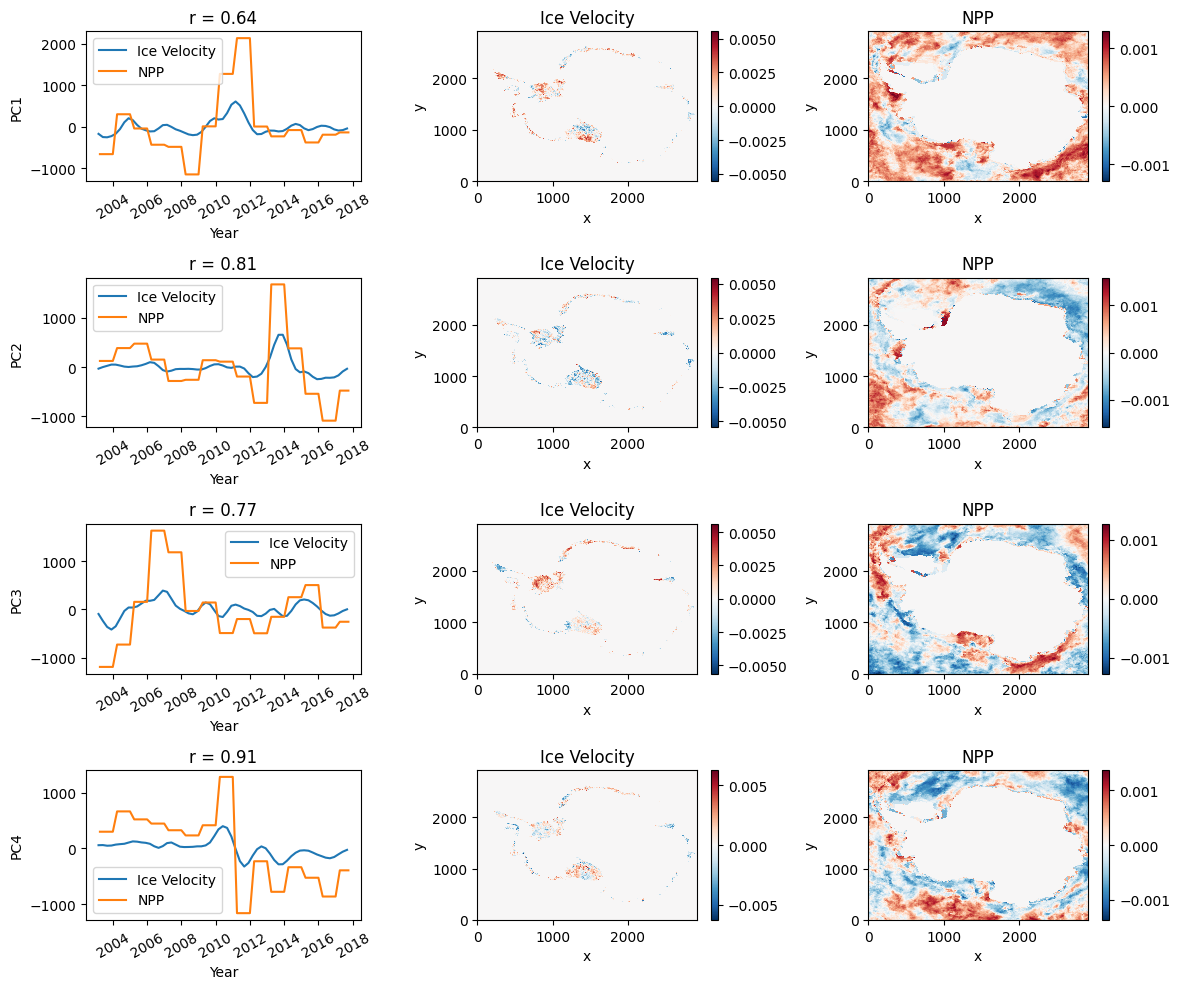

In [61]:
import inspect

model = xe.cross.MCA(n_modes=14, standardize=True)
#print(dir(model))


print(dir(model))
model.fit(ice_vels_no_nan_ds['melt'], regridded_to_ice_NPP_ds['NPP_regridded_to_ice'],dim='time')
comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)
s1 = scores1.values;
s2 = scores2.values
c1 = comps1.values;
c2 = comps2.values
print(path)
print(gridtype)
# Full path to the 'results' directory
results_dir = os.path.join(path, 'results')

# Check if the directory already exists
if os.path.exists(results_dir):
    print("Directory already exists")
else:
    # Create the directory if it doesn't exist
    os.makedirs(results_dir, exist_ok=True)
    print("Directory created!")

#how can you change from using cross.MCA to calling the subplots PCA1, PCA2, PCA3 etc ...
r_pears = [];
p_pears = []
r_spear = [];
p_spear = []
for m in range(1, 5):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2));
    p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2));
    p_spear.append(np.round(p, 2))
fig = plt.figure(figsize=(12, 10))

for i in range(0, 4):
    j = 3 * i + 1  # a = 2*(i+1) + i - 1

    plt.subplot(4, 3, j)
    scores1.sel(mode=i + 1).plot(label='Ice Velocity')
    scores2.sel(mode=i + 1).plot(label='NPP')
    plt.title('r = ' + str(r_spear[i]))
    plt.xlabel('Year');
    plt.ylabel('PC' + str(int(i + 1)))
    plt.xticks(rotation=30)
    plt.legend()

    plt.subplot(4, 3, j + 1)
    comps1.sel(mode=i + 1).plot()
    plt.title('Ice Velocity')
   # plt.gca().invert_yaxis()  # Flip y-axis as lat is descending, commented after trying to change this in both ds

    plt.subplot(4, 3, j + 2)
    comps2.sel(mode=i + 1).plot()
    plt.title('NPP')
  #  plt.gca().invert_yaxis()  # Flip y-axis if lat as descending, commented after trying to change this in both ds

fig.tight_layout()

# fig.savefig(path + 'results/MCA_output_' + gridtype + '_seas.png')
# compute squared covariance fraction (equivalent to explained variance in PCA)
sq_cov_frac = model.squared_covariance_fraction()
scf = sq_cov_frac.values
cum_sum = np.cumsum(scf)
print('Cumulative sum of squares:', cum_sum)
print('Squared covariance fraction:', scf)
print(type(cum_sum))
print(len(cum_sum))
mode_percent = []
for i in range(len(cum_sum)):
    if i == 0:
        each_mode_percent = float(cum_sum[i])
        mode_percent.append(each_mode_percent)
    else:
        each_mode_percent = float(cum_sum[i] - cum_sum[i - 1])
        mode_percent.append(each_mode_percent)
print('PCA fraction', mode_percent)


(2916, 2916)
(2916, 2916)
(2916, 2916)


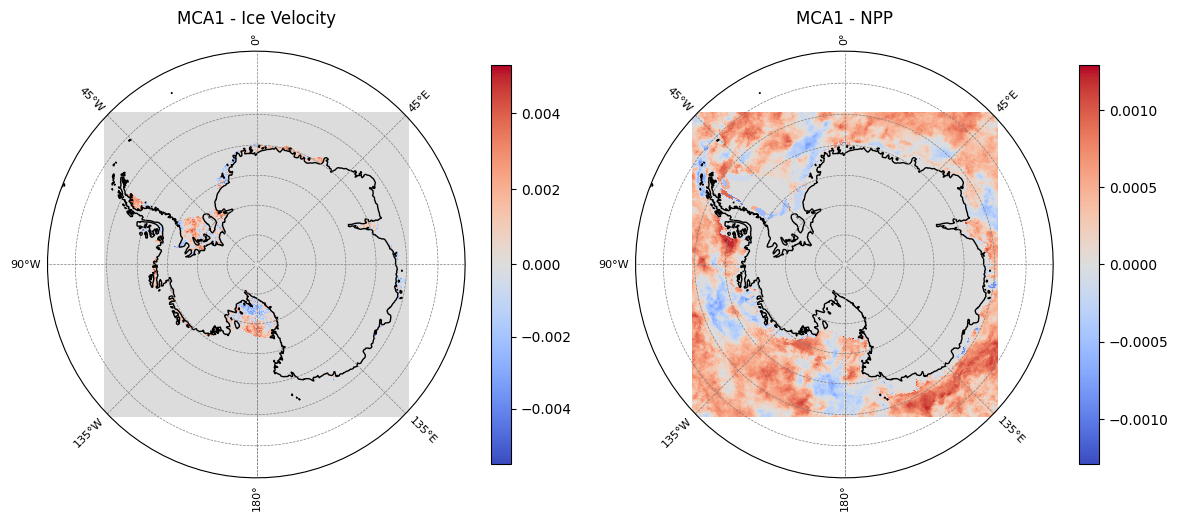

In [63]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import colors
from polar_plot_utils import plot_curvilinear_data

# Assuming comps1 and comps2 are already defined and contain your data
comp1 = comps1.sel(mode=1)
comp2 = comps2.sel(mode=1)
lon = comp1.lon.values
lat = comp1.lat.values
data1 = comp1.values
data2 = comp2.values


print(data1.shape)
print(lon.shape)
print(lat.shape)
# Create figure and axes for two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={'projection': ccrs.SouthPolarStereo()})

# Plot data1 (Left subplot)
pc1 = plot_curvilinear_data(axes[0], data1,lon, lat, "MCA1 - Ice Velocity")

# Plot data2 (Right subplot)
pc2 = plot_curvilinear_data(axes[1], data2, lon, lat, "MCA1 - NPP")

# Add colorbars for both subplots
# fig.colorbar(pc1, ax=axes[0], orientation='vertical', label='Amplitude', shrink=0.7, pad=0.05)
# fig.colorbar(pc2, ax=axes[1], orientation='vertical', label='Amplitude', shrink=0.7, pad=0.05)

plt.tight_layout()
plt.show()


plotting...
plotted 1


KeyboardInterrupt: 

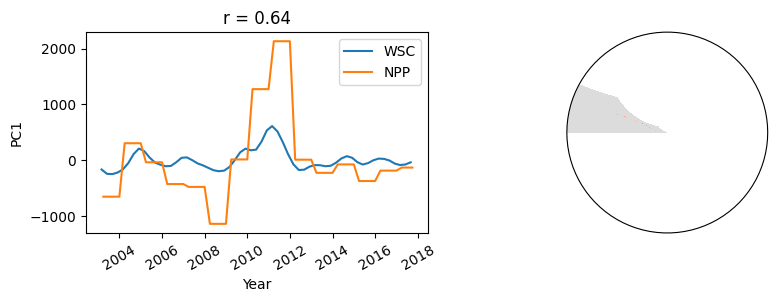

In [66]:
plt.savefig('/Users/iw2g24/PycharmProjects/SSH_project/results/NPP_mca/ice_vel_grid/ice_vel_poster.eps', format='eps')
plt.savefig('/Users/iw2g24/PycharmProjects/SSH_project/results/NPP_mca/ice_vel_grid/ice_vel_poster.svg', format='svg')